# Load Price Data

**Notebook overview** — this file loads **Round 4 price** CSVs (semicolon-separated), builds a **stitched, full-product** time panel, runs **mean-reversion / VEV / beta** analysis, then loads **trades** and plots **who traded when** and **notional cashflows by trader ID**.

The cell below **imports** `pandas` / `numpy` / `matplotlib` for tables, numerics, and line plots.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Load price files** — reads `prices_round_4_day_1/2/3.csv` from the current working directory (typically this folder). Each file is a long table: one row per `(timestamp, product)` with top-of-book columns and a `mid_price`.

'''
Data: adjust paths if the notebook is run from a different cwd. The separator is `;` as in many IMC-style exports. Large files — expect slow first read.
'''


In [2]:
prices_day_one_path = "prices_round_4_day_1.csv"
prices_day_two_path = "prices_round_4_day_2.csv"
prices_day_three_path = "prices_round_4_day_3.csv"

prices_one = pd.read_csv(prices_day_one_path, sep=";")
prices_two = pd.read_csv(prices_day_two_path, sep=";")
prices_three = pd.read_csv(prices_day_three_path, sep=';')

**Preview (`head`)** — quick sanity check of column names: `day`, `timestamp`, `product`, `bid_price_*` / `ask_price_*` / volumes, `mid_price`, and `profit_and_loss` (often zero in raw snapshots used for EDA).


In [3]:
prices_three.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,3,0,VELVETFRUIT_EXTRACT,5293,64,NaN,NaN,NaN,NaN,5298,22,5299.0,42.0,NaN,NaN,5295.5,0.0
1,3,0,VEV_4000,1285,9,1282.0,30.0,NaN,NaN,1307,9,1309.0,30.0,NaN,NaN,1296.0,0.0
2,3,0,VEV_5100,199,21,NaN,NaN,NaN,NaN,204,7,205.0,14.0,NaN,NaN,201.5,0.0
3,3,0,VEV_5200,118,7,117.0,14.0,NaN,NaN,121,21,NaN,NaN,NaN,NaN,119.5,0.0
4,3,0,VEV_5000,293,21,NaN,NaN,NaN,NaN,300,7,301.0,14.0,NaN,NaN,296.5,0.0


**Align timestamps across days** — each day uses `timestamp` 0, 100, …, 999900. Day 2 is shifted by `+1_000_000`, day 3 by `+2_000_000` so that after concatenation every row has a **unique** time key.

'''
Data analysis: the shift is a bookkeeping device so pivots and joins do not superimpose different sessions on the same index. It is not wall-clock time.
'''


In [4]:
prices_two['timestamp'] = prices_two['timestamp'] + 1000000
prices_three['timestamp'] = prices_three['timestamp'] + 2000000

**Stack and pivot** — `concat` all days, `pivot` to wide format (columns = product symbols, index = time). Then **filter** to rows where **all** of the named products have **strictly positive** mids.

'''
Data analysis: the “all products positive” filter defines a **common support** for cross-sectional stats. It drops ticks where any name is missing or at zero (e.g. illiquid or wing at floor), so correlations and betas are comparable — at the cost of a shorter time series.
'''


In [5]:
combined_prices_df = pd.concat([prices_one, prices_two, prices_three])
combined_prices_piv = combined_prices_df.pivot(index="timestamp", columns="product", values="mid_price")

combined_prices_piv = combined_prices_piv[(combined_prices_piv['HYDROGEL_PACK'] > 0) & (combined_prices_piv['VELVETFRUIT_EXTRACT'] > 0) & (combined_prices_piv['VEV_4000'] > 0) & (combined_prices_piv['VEV_4500'] > 0) & (combined_prices_piv['VEV_5000'] > 0) & (combined_prices_piv['VEV_5100'] > 0) & (combined_prices_piv['VEV_5200'] > 0) & (combined_prices_piv['VEV_5300'] > 0) & (combined_prices_piv['VEV_5400'] > 0) & (combined_prices_piv['VEV_5500'] > 0) & (combined_prices_piv['VEV_6000'] > 0) & (combined_prices_piv['VEV_6500'] > 0)]

**Price plot: HYDROGEL_PACK** — `mid` over the full **offset** time index. Use it to see level, drifts, and whether day boundaries look like level shifts or continuous paths.


<Axes: xlabel='timestamp'>

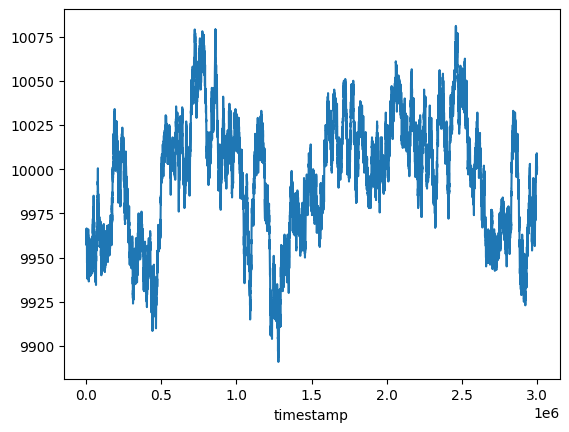

In [6]:
combined_prices_piv['HYDROGEL_PACK'].plot()

**Price plot: VELVETFRUIT_EXTRACT** — the “spot-like” name; compare volatility and any trend to HYDRO and to the **VEV_*** block later. This series drives synthetic **option intrinsic** in the VEV section.


<Axes: xlabel='timestamp'>

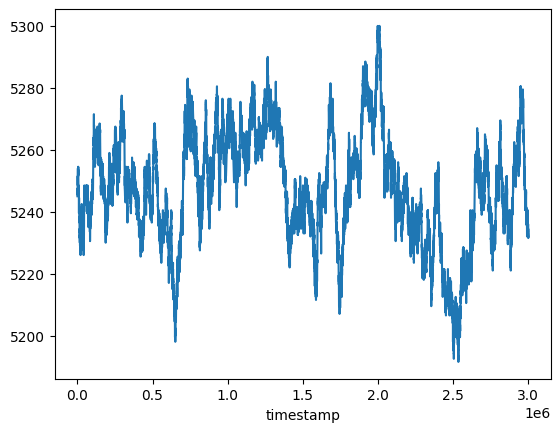

In [7]:
combined_prices_piv['VELVETFRUIT_EXTRACT'].plot()

## Single-Name Mean Reversion

The Johansen result above is sensitive to specification, so the more reliable next step is to treat `HYDROGEL_PACK` and `VELVETFRUIT_EXTRACT` as separate mean-reverting series. The cell below estimates stationarity, AR(1)-style half-life, rolling z-score behavior, and how often 1.5-2.5 sigma entries revert back inside a 0.5 sigma exit band within one half-life.

**Code cell: single-name mean reversion (HYDRO + VELVET)** — runs *after* the **Single-Name Mean Reversion** section header. It builds `single_name_df` from the combined pivot, then for each name computes summary stats and a threshold study.

'''
Data analysis (concrete definitions):
- **ADF (`adfuller`) p-value** — from Augmented Dickey–Fuller on **levels**; very small p → reject unit root, consistent with **stationary** or at least *mean-reverting-like* data. On noisy mids, still interpret with care.
- **AR(1) / half-life** — OLS of `x_t` on `x_{t-1}`; if slope `β` is in (0,1), half-life in ticks = `-log(2)/log(β)` = typical time for an AR(1) shock to halve. If `β ≥ 1` or `β ≤ 0`, half-life is not finite in that toy model.
- **Rolling z-score** (window 1000): `z = (P - μ_roll) / σ_roll` for entry signals when |z| is “large.”
- **`entry_threshold_summary`** — for entry thresholds 1.5, 2, 2.5 σ: detects *crossings* of |z| above threshold; for each crossing looks **forward one half-life (rounded)** and records **signed** reversion in the direction a contrarian would want (`-sign(z) * (P_{t+h}-P_t)`), the fraction of times that move is **positive** (“hit rate”), and whether |z| returns inside a **0.5** band within that horizon. Also reports long-run **entry rate** of such crossings.
- **Figures** — z-score over time with ±2 and ±0.5 reference bands.

*Note: the prose in the section header mentions **Johansen**; this code cell does **not** run a Johansen test — it is **univariate** only.*
'''


,mean_price,std_price,adf_pvalue,ar1_beta,half_life_ticks,pct_abs_z_gt_2,pct_abs_z_gt_3
product,,,,,,,
HYDROGEL_PACK,9994.6543,34.6233,0.0001,0.998,349.6719,0.1150,0.0162
VELVETFRUIT_EXTRACT,5247.6487,18.0771,0.0003,0.998,351.9036,0.1307,0.0108


,product,threshold,entry_rate,count,avg_signed_reversion,hit_rate,exit_band_hit_rate
0,HYDROGEL_PACK,1.5,0.0176,523,10.0880,0.6252,0.8547
1,HYDROGEL_PACK,2.0,0.0116,345,8.3899,0.5797,0.7623
2,HYDROGEL_PACK,2.5,0.0047,140,13.0036,0.7214,0.7786
3,VELVETFRUIT_EXTRACT,1.5,0.0172,508,6.0069,0.6378,0.8071
4,VELVETFRUIT_EXTRACT,2.0,0.0116,345,8.2580,0.7710,0.8000
5,VELVETFRUIT_EXTRACT,2.5,0.0057,170,11.2206,0.7941,0.8000


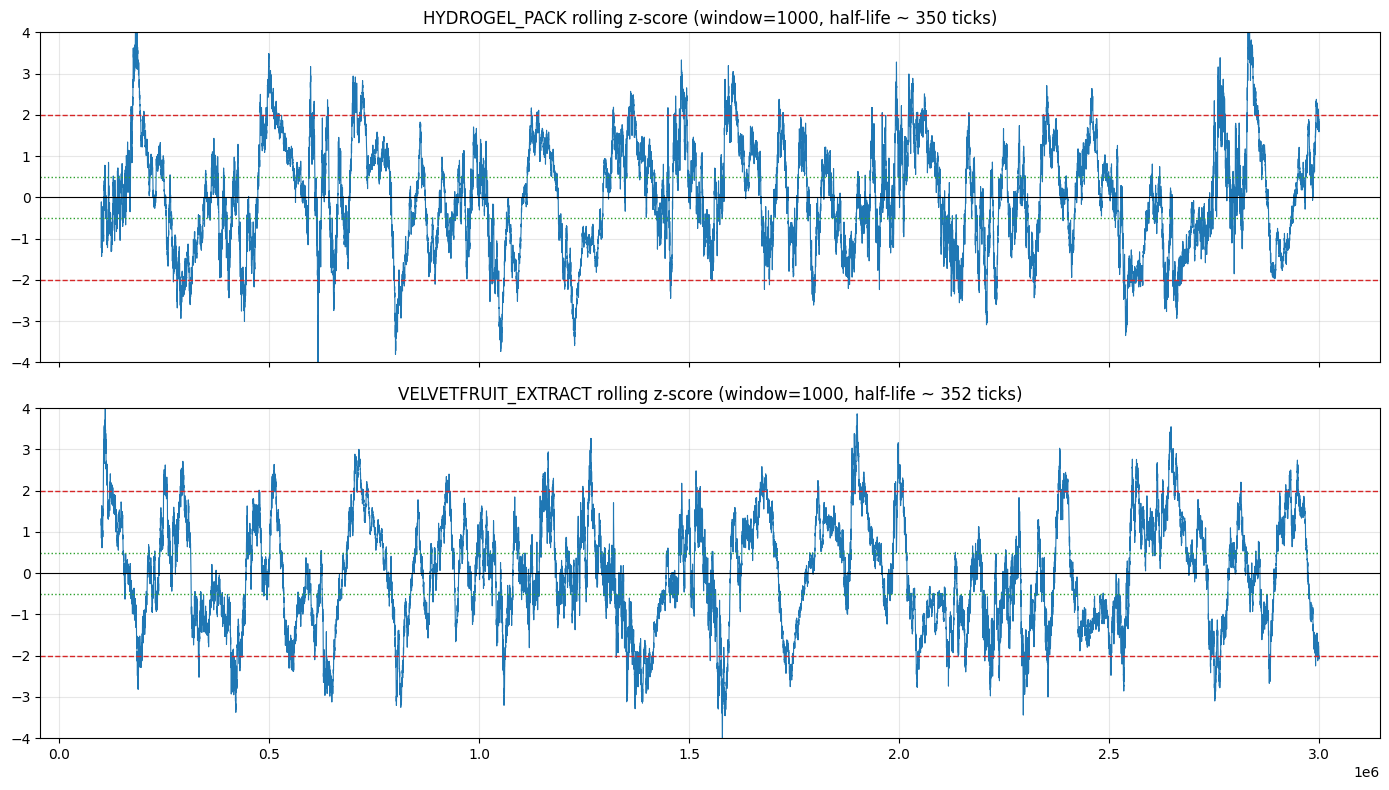

In [8]:
from statsmodels.tsa.stattools import adfuller

single_name_df = combined_prices_piv[["HYDROGEL_PACK", "VELVETFRUIT_EXTRACT"]].dropna().copy()


def estimate_half_life(series):
    lagged = series.shift(1).dropna()
    current = series.loc[lagged.index]
    ar1_beta = np.polyfit(lagged, current, 1)[0]
    half_life = np.inf if ar1_beta <= 0 or ar1_beta >= 1 else -np.log(2) / np.log(ar1_beta)
    return float(ar1_beta), float(half_life)


def rolling_zscore(series, window):
    rolling_mean = series.rolling(window).mean()
    rolling_std = series.rolling(window).std()
    return (series - rolling_mean) / rolling_std


def entry_threshold_summary(series, half_life, window=1000, thresholds=(1.5, 2.0, 2.5), exit_band=0.5):
    zscore = rolling_zscore(series, window)
    horizon = max(1, int(round(half_life)))
    forward_change = series.shift(-horizon) - series
    rows = []
    for threshold in thresholds:
        entries = (zscore.abs() >= threshold) & (zscore.shift(1).abs() < threshold)
        entry_index = zscore.index[entries.fillna(False)]
        signed_edge = []
        exit_hits = []
        for timestamp in entry_index:
            loc = zscore.index.get_loc(timestamp)
            if loc + horizon >= len(series):
                continue
            signed_edge.append(-np.sign(zscore.iloc[loc]) * forward_change.iloc[loc])
            future_window = zscore.iloc[loc + 1:loc + horizon + 1]
            exit_hits.append(float((future_window.abs() <= exit_band).any()))
        signed_edge = pd.Series(signed_edge, dtype=float)
        exit_hits = pd.Series(exit_hits, dtype=float)
        rows.append(
            {
                "threshold": threshold,
                "entry_rate": float(entries.mean()),
                "count": int(signed_edge.shape[0]),
                "avg_signed_reversion": float(signed_edge.mean()),
                "hit_rate": float((signed_edge > 0).mean()),
                "exit_band_hit_rate": float(exit_hits.mean()),
            }
        )
    return pd.DataFrame(rows)


rolling_window = 1000
single_name_summary_rows = []
single_name_threshold_tables = []
single_name_zscores = {}

for product in single_name_df.columns:
    series = single_name_df[product]
    ar1_beta, half_life = estimate_half_life(series)
    zscore = rolling_zscore(series, rolling_window)
    single_name_zscores[product] = zscore
    single_name_summary_rows.append(
        {
            "product": product,
            "mean_price": float(series.mean()),
            "std_price": float(series.std()),
            "adf_pvalue": float(adfuller(series)[1]),
            "ar1_beta": ar1_beta,
            "half_life_ticks": half_life,
            "pct_abs_z_gt_2": float((zscore.abs() > 2).mean()),
            "pct_abs_z_gt_3": float((zscore.abs() > 3).mean()),
        }
    )
    product_thresholds = entry_threshold_summary(series, half_life, window=rolling_window)
    product_thresholds.insert(0, "product", product)
    single_name_threshold_tables.append(product_thresholds)

single_name_summary = pd.DataFrame(single_name_summary_rows).set_index("product")
single_name_thresholds = pd.concat(single_name_threshold_tables, ignore_index=True)

display(single_name_summary.round(4))
display(single_name_thresholds.round(4))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for ax, product in zip(axes, single_name_df.columns):
    ax.plot(single_name_zscores[product].index, single_name_zscores[product], linewidth=0.8)
    ax.axhline(2.0, color="tab:red", linestyle="--", linewidth=1)
    ax.axhline(-2.0, color="tab:red", linestyle="--", linewidth=1)
    ax.axhline(0.5, color="tab:green", linestyle=":", linewidth=1)
    ax.axhline(-0.5, color="tab:green", linestyle=":", linewidth=1)
    ax.axhline(0.0, color="black", linewidth=0.8)
    ax.set_ylim(-4, 4)
    ax.set_title(
        f"{product} rolling z-score (window={rolling_window}, half-life ~ {single_name_summary.loc[product, 'half_life_ticks']:.0f} ticks)"
    )
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## VEV Strike Ladder

The VEV strip is the more structured object in round 3. The useful diagnostics here are:

- how closely each strike tracks intrinsic value
- where time value is concentrated across strikes
- how much each contract moves when `VELVETFRUIT_EXTRACT` moves

A cross-beta between `HYDROGEL_PACK` and `VELVETFRUIT_EXTRACT` is not very useful because their relationship is weak and unstable. A beta of `VEV_*` changes versus `VELVETFRUIT_EXTRACT` changes is useful because it behaves like an empirical delta.

**Code cell: VEV cross-section (after the VEV Strike Ladder section header)** — sorts `VEV_*` by strike, aligns with `VELVETFRUIT_EXTRACT`, and compares option mids to a **synthetic intrinsic** `max(velvet - K, 0)`.

'''
Data analysis:
- **intrinsic (per row)** — treats `VELVETFRUIT_EXTRACT` as the underlying **S**; each `VEV_*` column’s intrinsic is `max(S-K,0)` in **price** units, like a call payoff lower bound in the *same* numeraire as the option mid.
- **mean_time_value** — mean( mid − intrinsic ): average **excess** of the market mid over intrinsic — “time value / smile / microstructure” in one number per strike, under this crude decomposition.
- **corr_with_velvet / corr_with_intrinsic** — linear correlation of **option mid** with **spot** and with **synthetic intrinsic path**; shows whether the option tracks the spot or the *smoothed* intrinsic more closely.
- **diff_beta_to_velvet** — `cov(Δoption, Δvelvet) / var(Δvelvet)` = **slope of Δoption on Δvelvet** (empirical “delta in tick space” if you treat velvet diff as the factor).
- **pct_at_global_floor** — share of time the mid equals the **global minimum** over all VEV columns (e.g. wings parked at 0.5 in many samples).
- **monotonic_violations** — counts violations of **call monotonicity in strike** (higher strike should not have a **higher** price than a lower strike in a frictionless one-underlying world); positive counts point to microstructure, discreteness, or data quirks.
- **Plots** — (1) mean option vs mean intrinsic, (2) mean time value by strike, (3) diff beta by strike.
'''


,strike,mean_price,std_price,corr_with_velvet,corr_with_intrinsic,mean_time_value,pct_at_global_floor,diff_beta_to_velvet
VEV_4000,4000,1247.6566,18.1013,0.9989,0.9989,0.0078,0.0000,0.7416
VEV_4500,4500,747.6568,18.0924,0.9991,0.9991,0.0080,0.0000,0.6682
VEV_5000,5000,251.1446,17.4555,0.9969,0.9969,3.4959,0.0000,0.6611
VEV_5100,5100,160.8633,16.1274,0.9818,0.9818,13.2146,0.0000,0.5863
VEV_5200,5200,88.9935,13.3470,0.9287,0.9286,41.3318,0.0000,0.4371
VEV_5300,5300,41.1763,9.1430,0.8500,NaN,41.1763,0.0000,0.2608
VEV_5400,5400,12.6298,4.1493,0.7796,NaN,12.6298,0.0000,0.1123
VEV_5500,5500,4.7078,2.2053,0.6541,NaN,4.7078,0.0087,0.0433
VEV_6000,6000,0.5000,0.0000,NaN,NaN,0.5000,1.0000,0.0000
VEV_6500,6500,0.5000,0.0000,NaN,NaN,0.5000,1.0000,0.0000


{'global_floor': 0.5, 'monotonic_violations': 0, 'always_at_floor': ['VEV_6000', 'VEV_6500']}


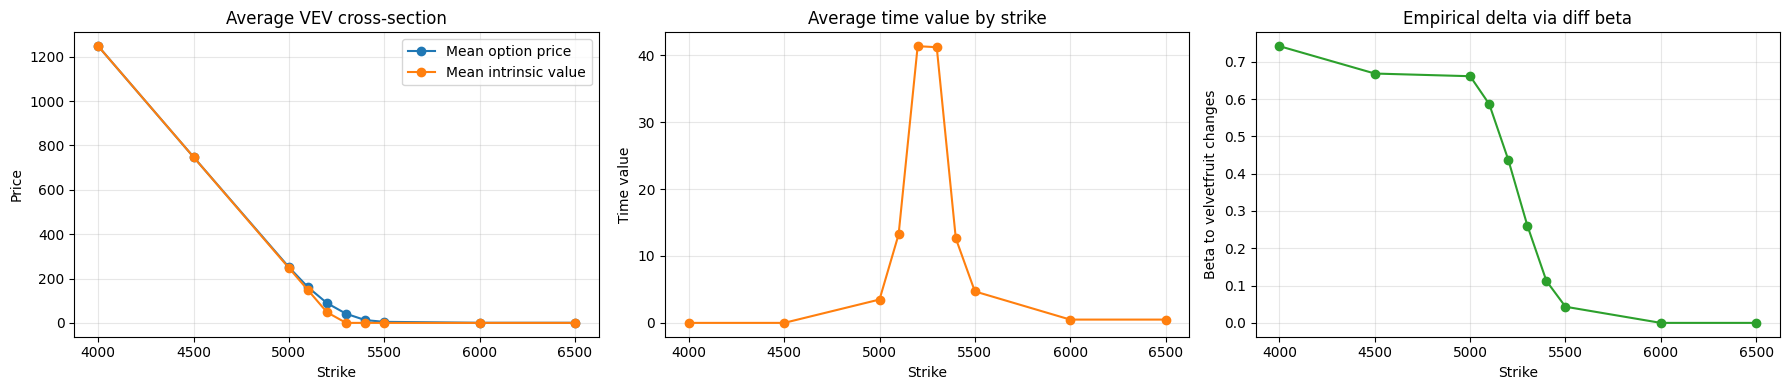

In [9]:
vev_columns = [col for col in combined_prices_piv.columns if col.startswith("VEV_")]
vev_strikes = pd.Series({col: int(col.split("_")[1]) for col in vev_columns}).sort_values()
vev_ordered = combined_prices_piv[vev_strikes.index].dropna().copy()
velvet_series = combined_prices_piv.loc[vev_ordered.index, "VELVETFRUIT_EXTRACT"]


def safe_corr(left, right):
    if left.std() == 0 or right.std() == 0:
        return np.nan
    return float(left.corr(right))


vev_intrinsic = pd.DataFrame(
    {
        col: np.maximum(velvet_series - strike, 0)
        for col, strike in vev_strikes.items()
    },
    index=vev_ordered.index,
)

global_floor = float(vev_ordered.min().min())
velvet_diff = velvet_series.diff()

vev_summary = pd.DataFrame(
    {
        "strike": vev_strikes,
        "mean_price": vev_ordered.mean(),
        "std_price": vev_ordered.std(),
        "corr_with_velvet": vev_ordered.apply(lambda series: safe_corr(series, velvet_series)),
        "corr_with_intrinsic": vev_ordered.apply(
            lambda series: safe_corr(series, vev_intrinsic[series.name])
        ),
        "mean_time_value": (vev_ordered - vev_intrinsic).mean(),
        "pct_at_global_floor": vev_ordered.apply(
            lambda series: float((series == global_floor).mean())
        ),
        "diff_beta_to_velvet": vev_ordered.apply(
            lambda series: series.diff().cov(velvet_diff) / velvet_diff.var()
        ),
    }
).sort_values("strike")

display(vev_summary.round(4))

monotonic_violations = int((vev_ordered.diff(axis=1).dropna(axis=1) > 0).sum().sum())
full_floor_strikes = vev_summary.index[vev_summary["pct_at_global_floor"] == 1.0].tolist()
print(
    {
        "global_floor": global_floor,
        "monotonic_violations": monotonic_violations,
        "always_at_floor": full_floor_strikes,
    }
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(vev_summary["strike"], vev_summary["mean_price"], marker="o", label="Mean option price")
axes[0].plot(
    vev_summary["strike"],
    vev_intrinsic.mean().reindex(vev_summary.index),
    marker="o",
    label="Mean intrinsic value",
)
axes[0].set_title("Average VEV cross-section")
axes[0].set_xlabel("Strike")
axes[0].set_ylabel("Price")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(vev_summary["strike"], vev_summary["mean_time_value"], marker="o", color="tab:orange")
axes[1].set_title("Average time value by strike")
axes[1].set_xlabel("Strike")
axes[1].set_ylabel("Time value")
axes[1].grid(alpha=0.3)

axes[2].plot(vev_summary["strike"], vev_summary["diff_beta_to_velvet"], marker="o", color="tab:green")
axes[2].set_title("Empirical delta via diff beta")
axes[2].set_xlabel("Strike")
axes[2].set_ylabel("Beta to velvetfruit changes")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## VEV Beta vs VELVETFRUIT_EXTRACT

This section estimates beta for each `VEV_*` contract relative to `VELVETFRUIT_EXTRACT`. `price_change_beta` uses first differences and is the closest empirical delta; `return_beta` is included as a scale-free cross-check.

**Code cell: VEV–VELVET betas (after the VEV beta section header)** — for each `VEV_*` column, aligns with velvet and reports:

- **price_change_beta** — `cov(ΔV, Δvelvet) / var(Δvelvet)` (same as before but in a single dedicated table).
- **return_beta** — the same with **percentage changes** (scale-free in price level).
- **change_correlation** — `corr(ΔV, Δvelvet)`.

'''
Data analysis: return-based beta is more comparable when tick sizes differ; price-change beta matches “dollar” intuition on this ladder. The plot overlays **price_change_beta** and **return_beta** by strike to see how the smile of sensitivity looks.
'''


,strike,price_change_beta,return_beta,change_correlation
VEV_4000,4000,0.7416,3.1188,0.5810
VEV_4500,4500,0.6682,4.6948,0.5955
VEV_5000,5000,0.6611,13.8707,0.7556
VEV_5100,5100,0.5863,19.2726,0.7634
VEV_5200,5200,0.4371,26.1428,0.7306
VEV_5300,5300,0.2608,34.1309,0.6201
VEV_5400,5400,0.1123,48.3964,0.5033
VEV_5500,5500,0.0433,54.0380,0.3102
VEV_6000,6000,0.0000,0.0000,NaN
VEV_6500,6500,0.0000,0.0000,NaN


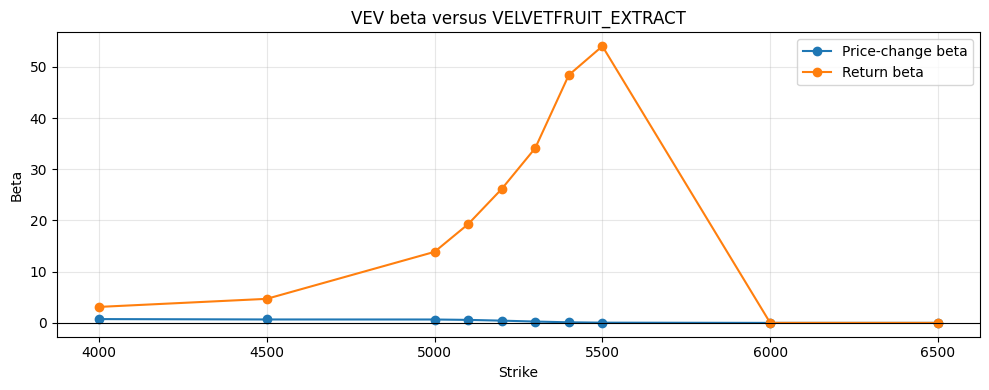

In [10]:
vev_beta_columns = sorted(
    [col for col in combined_prices_piv.columns if col.startswith("VEV_")],
    key=lambda col: int(col.split("_")[1]),
)

vev_beta_frame = combined_prices_piv[["VELVETFRUIT_EXTRACT", *vev_beta_columns]].dropna().copy()
velvet_price_changes = vev_beta_frame["VELVETFRUIT_EXTRACT"].diff()
velvet_returns = vev_beta_frame["VELVETFRUIT_EXTRACT"].pct_change()


def align_pair(reference, target):
    return pd.concat(
        [reference.rename("reference"), target.rename("target")],
        axis=1,
    ).dropna()


def compute_beta(reference, target):
    aligned = align_pair(reference, target)
    if aligned.shape[0] < 2:
        return np.nan
    reference_var = aligned["reference"].var()
    if pd.isna(reference_var) or reference_var == 0:
        return np.nan
    return float(aligned["target"].cov(aligned["reference"]) / reference_var)


def compute_corr(reference, target):
    aligned = align_pair(reference, target)
    if aligned.shape[0] < 2:
        return np.nan
    reference_std = aligned["reference"].std()
    target_std = aligned["target"].std()
    if (
        pd.isna(reference_std)
        or pd.isna(target_std)
        or reference_std == 0
        or target_std == 0
    ):
        return np.nan
    return float(aligned["target"].corr(aligned["reference"]))


vev_beta_summary = pd.DataFrame(
    {
        "strike": [int(col.split("_")[1]) for col in vev_beta_columns],
        "price_change_beta": [
            compute_beta(velvet_price_changes, vev_beta_frame[col].diff())
            for col in vev_beta_columns
        ],
        "return_beta": [
            compute_beta(velvet_returns, vev_beta_frame[col].pct_change())
            for col in vev_beta_columns
        ],
        "change_correlation": [
            compute_corr(velvet_price_changes, vev_beta_frame[col].diff())
            for col in vev_beta_columns
        ],
    },
    index=vev_beta_columns,
).sort_values("strike")

display(vev_beta_summary.round(4))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    vev_beta_summary["strike"],
    vev_beta_summary["price_change_beta"],
    marker="o",
    label="Price-change beta",
)
ax.plot(
    vev_beta_summary["strike"],
    vev_beta_summary["return_beta"],
    marker="o",
    label="Return beta",
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("VEV beta versus VELVETFRUIT_EXTRACT")
ax.set_xlabel("Strike")
ax.set_ylabel("Beta")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

**Trades section** — the next cells read **tape** files, preview columns, and define a **scatter timeline** of prints by **buyer** / **seller** id. This is for **flow** and **participation**, not the same as mark-to-market PnL of a strategy.


# Load Trade Data

**Load `trades_round_4_day_*.csv`** — same `;` separator. Each row is a fill: who bought, who sold, `symbol` (product), `price`, `quantity`, and `timestamp`.


In [11]:
trade_day_one_path = "trades_round_4_day_1.csv"
trade_day_two_path = "trades_round_4_day_2.csv"
trade_day_three_path = "trades_round_4_day_3.csv"

trades_one = pd.read_csv(trade_day_one_path, sep=";")
trades_two = pd.read_csv(trade_day_two_path, sep=";")
trades_three = pd.read_csv(trade_day_three_path, sep=';')

**Preview (day 3)** — `trades_three.head()` shows a sample of the schema; you can mirror with `trades_one` / `trades_two` to compare activity across days.


In [49]:
trades_three.head()

,timestamp,buyer,seller,symbol,currency,price,quantity,total_value
0,1700,Mark 14,Mark 38,VEV_4000,XIRECS,1287.0,2,2574.0
1,4400,Mark 38,Mark 14,HYDROGEL_PACK,XIRECS,10028.0,6,60168.0
2,4500,Mark 14,Mark 38,HYDROGEL_PACK,XIRECS,10010.0,3,30030.0
3,8100,Mark 14,Mark 38,HYDROGEL_PACK,XIRECS,10008.0,5,50040.0
4,8700,Mark 38,Mark 14,VEV_4000,XIRECS,1310.0,2,2620.0


**Helper: `plot_product_activity(df, product_symbol)`** — long-form preparation for seaborn: duplicate each trade on the **buy** side and on the **sell** side, then `relplot` with time on x, price on y, **color = counterparty**, and **separate columns** for “Bought” vs “Sold.”

'''
Data analysis: the plot is **description**, not a structural model — it highlights **who** is on each side at which prices over time, whether prints cluster, and if certain IDs are persistently one-sided. It does *not* show inventory or PnL without a full position mark.
'''


In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_product_activity(df, product_symbol):
    """
    Plots the price over time for a specific product, 
    color-coded by the individual buyers and sellers.
    """
    
    # 1. Filter the dataframe for the chosen product
    product_df = df[df['symbol'] == product_symbol].copy()
    
    if product_df.empty:
        print(f"No trading data found for product: {product_symbol}")
        return
        
    # 2. Isolate the buyer's side (Keep timestamp instead of trader name)
    buyers_df = product_df[['timestamp', 'buyer', 'price']].copy()
    buyers_df.rename(columns={'buyer': 'trader'}, inplace=True)
    buyers_df['action'] = 'Bought'

    # 3. Isolate the seller's side
    sellers_df = product_df[['timestamp', 'seller', 'price']].copy()
    sellers_df.rename(columns={'seller': 'trader'}, inplace=True)
    sellers_df['action'] = 'Sold'

    # 4. Combine into a unified DataFrame for Seaborn
    trade_details = pd.concat([buyers_df, sellers_df], ignore_index=True)

    # 5. Plot the data using a relational plot (scatter)
    sns.set_theme(style="whitegrid")
    g = sns.relplot(
        data=trade_details,
        x='timestamp',     # X-axis is now time
        y='price',         # Y-axis is price
        hue='trader',      # Color/Legend is now the individual trader
        col='action',      # Splits the graph into "Bought" and "Sold" panels
        kind='scatter',    # Plots dots for each trade over time
        alpha=0.8,         # Slight transparency
        s=75,              # Makes the dots slightly larger for visibility
        height=5,
        aspect=1.5,        # Makes the charts wider to better show time progression
        palette='tab10'    # A good color palette for distinguishing distinct categories (traders)
    )

    # 6. Formatting and Labels
    g.set_axis_labels("Timestamp", "Trade Price (XIRECS)")
    g.set_titles("{col_name} Activity") 
    
    # Add a main title above the subplots
    g.fig.suptitle(f"Trade Execution Timeline: {product_symbol}", y=1.05, fontsize=14, fontweight='bold')

    plt.show()

**Day 1 trade timelines** — the following cells call `plot_product_activity(trades_one, ...)` for **HYDROGEL_PACK**, **VELVETFRUIT_EXTRACT**, and every **VEV_*** in order through **VEV_6500**. Use them to eyeball which names had the most prints and whether prices crossed wide spreads in the tape.


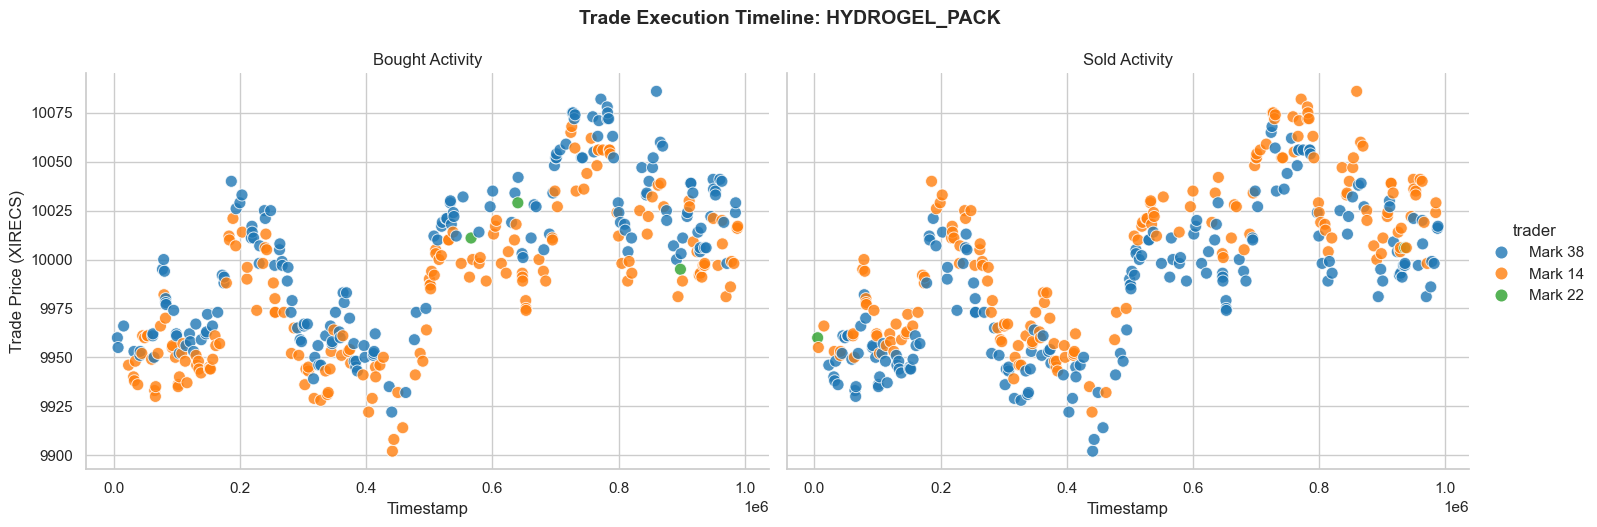

In [13]:
plot_product_activity(trades_one, 'HYDROGEL_PACK')

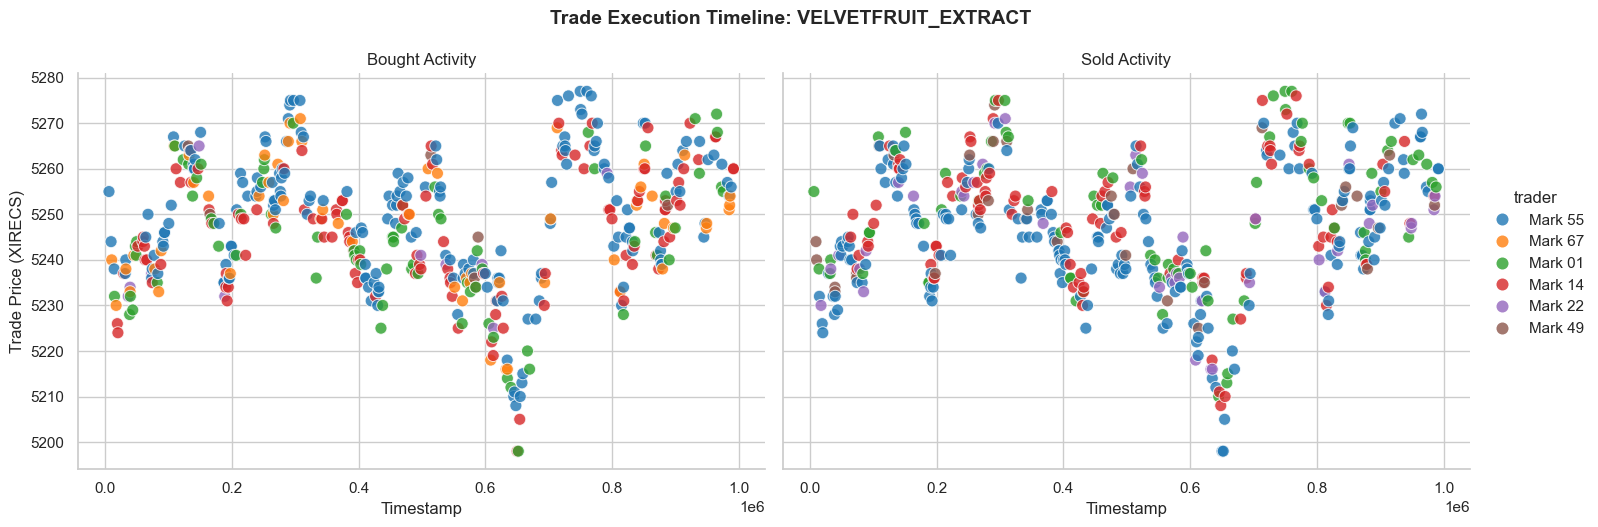

In [14]:
plot_product_activity(trades_one, 'VELVETFRUIT_EXTRACT')

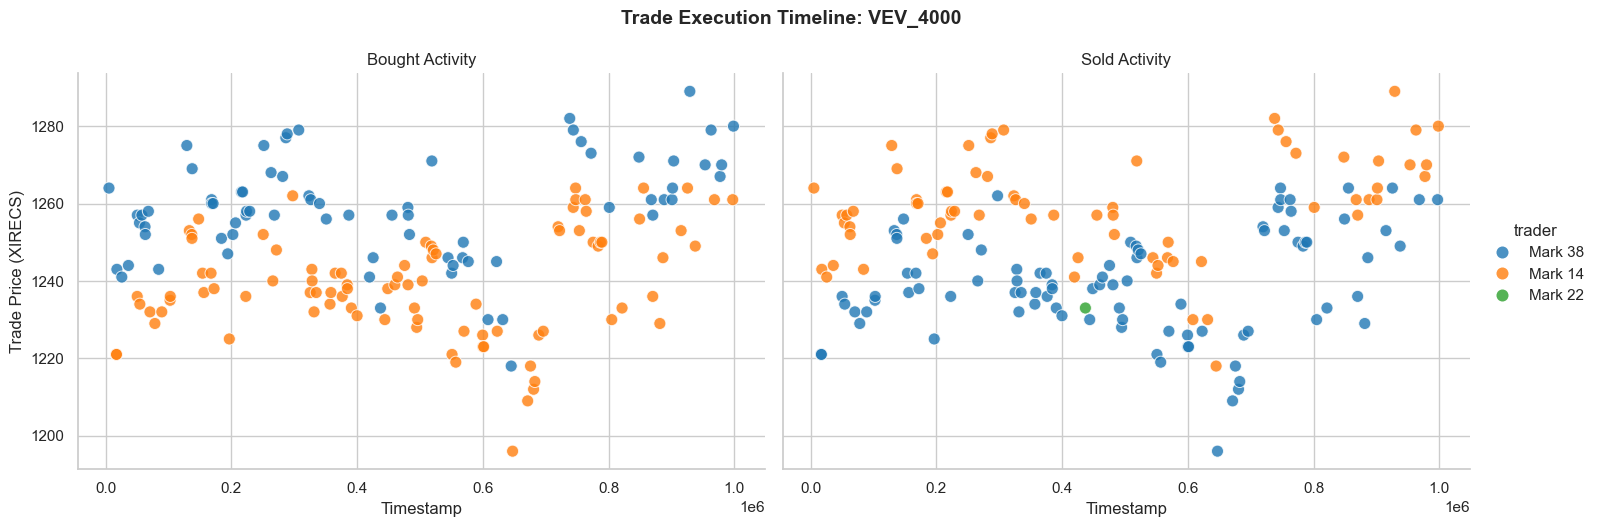

In [15]:
plot_product_activity(trades_one, 'VEV_4000')

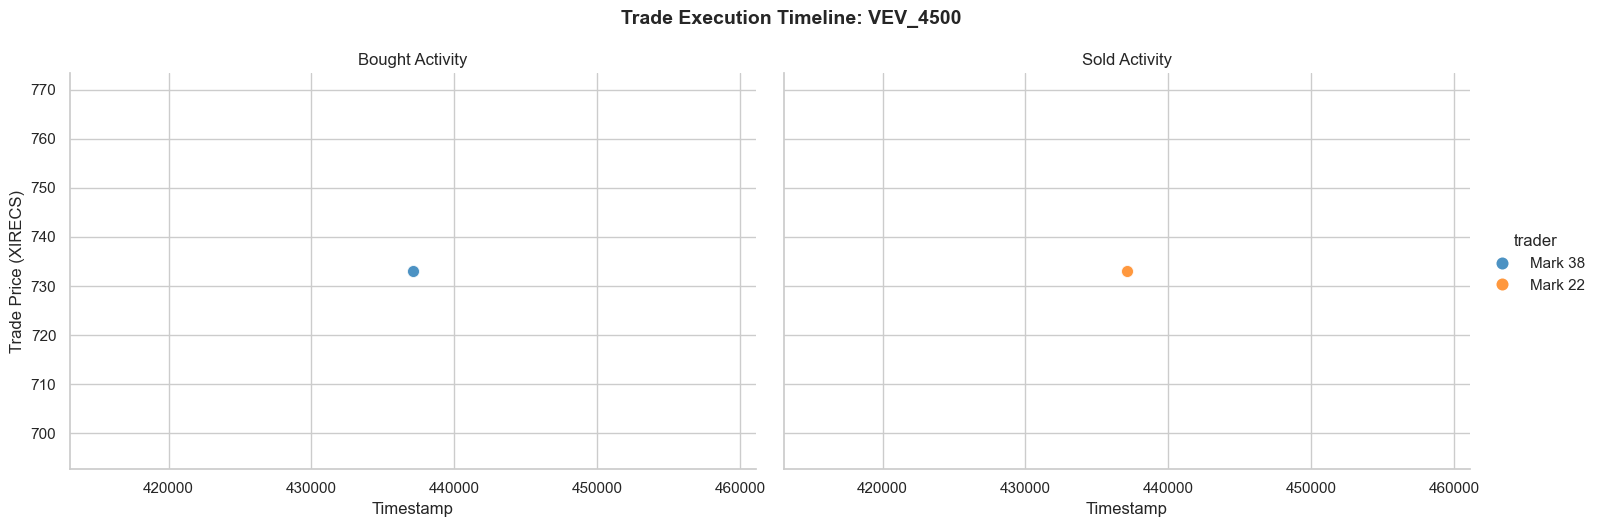

In [16]:
plot_product_activity(trades_one, 'VEV_4500')

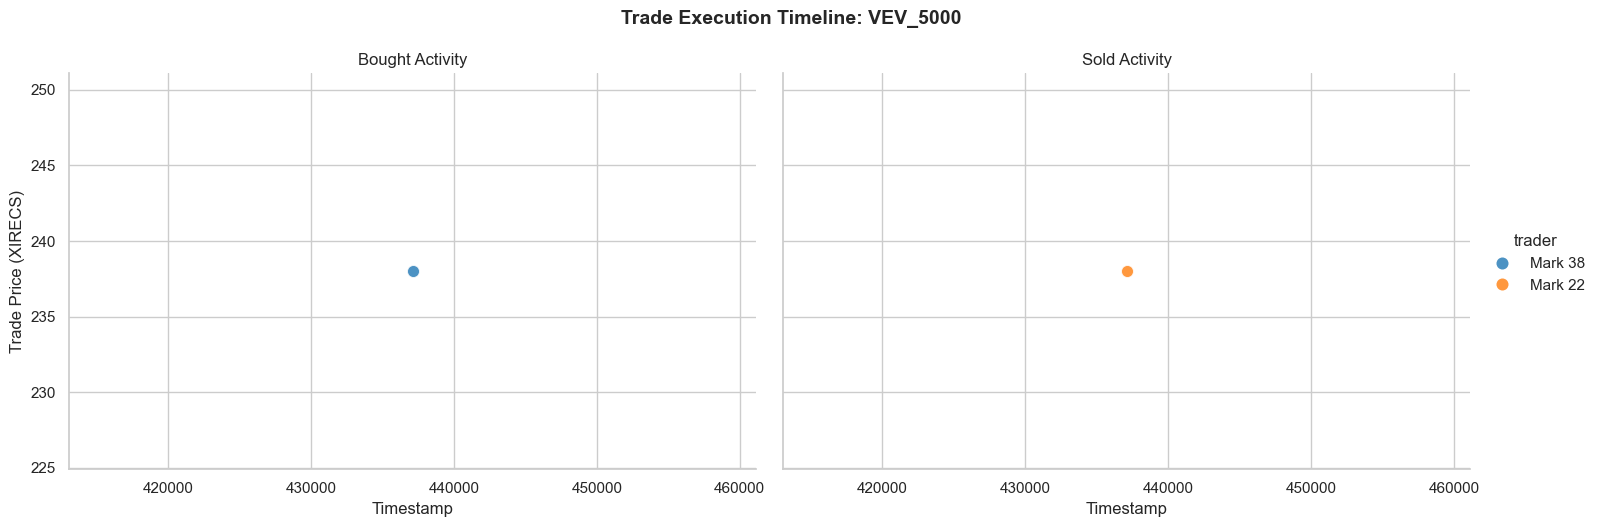

In [17]:
plot_product_activity(trades_one, 'VEV_5000')

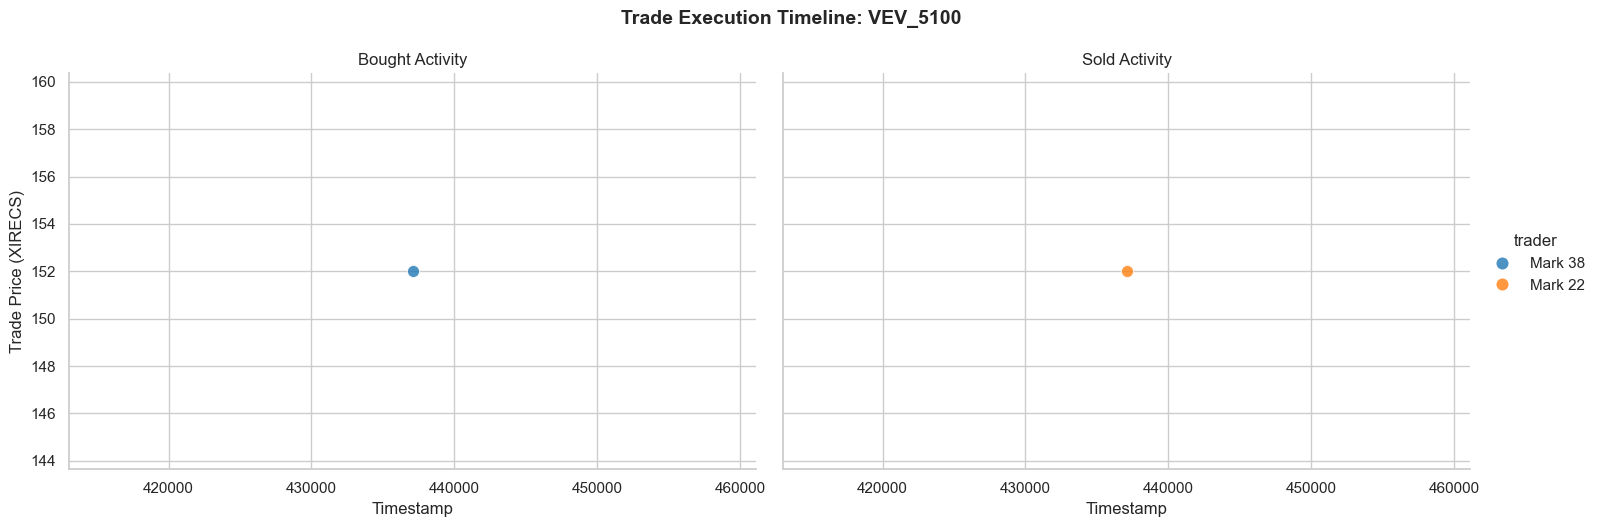

In [18]:
plot_product_activity(trades_one, 'VEV_5100')

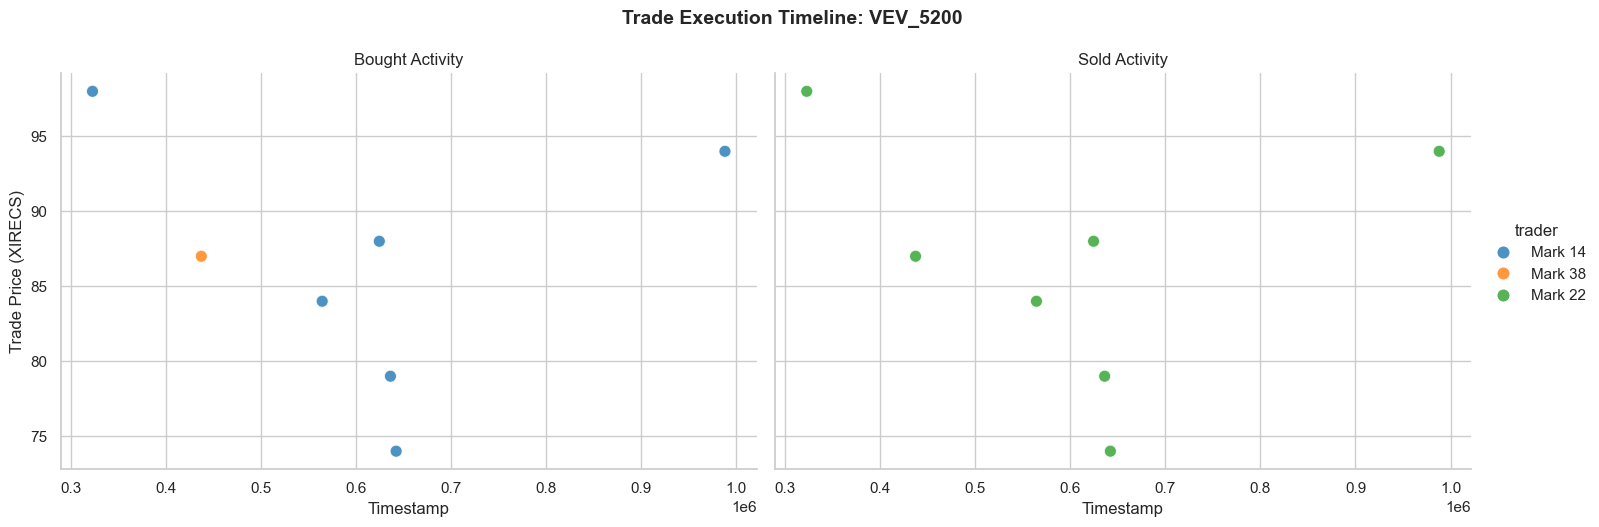

In [19]:
plot_product_activity(trades_one, 'VEV_5200')

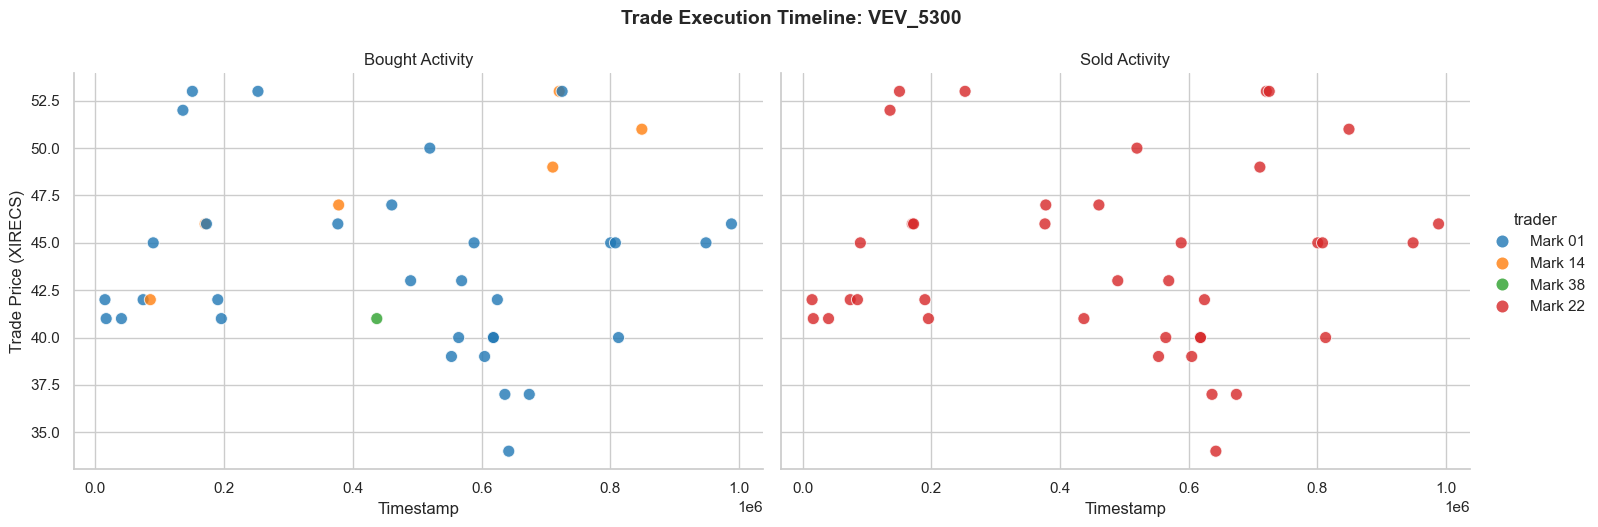

In [20]:
plot_product_activity(trades_one, 'VEV_5300')

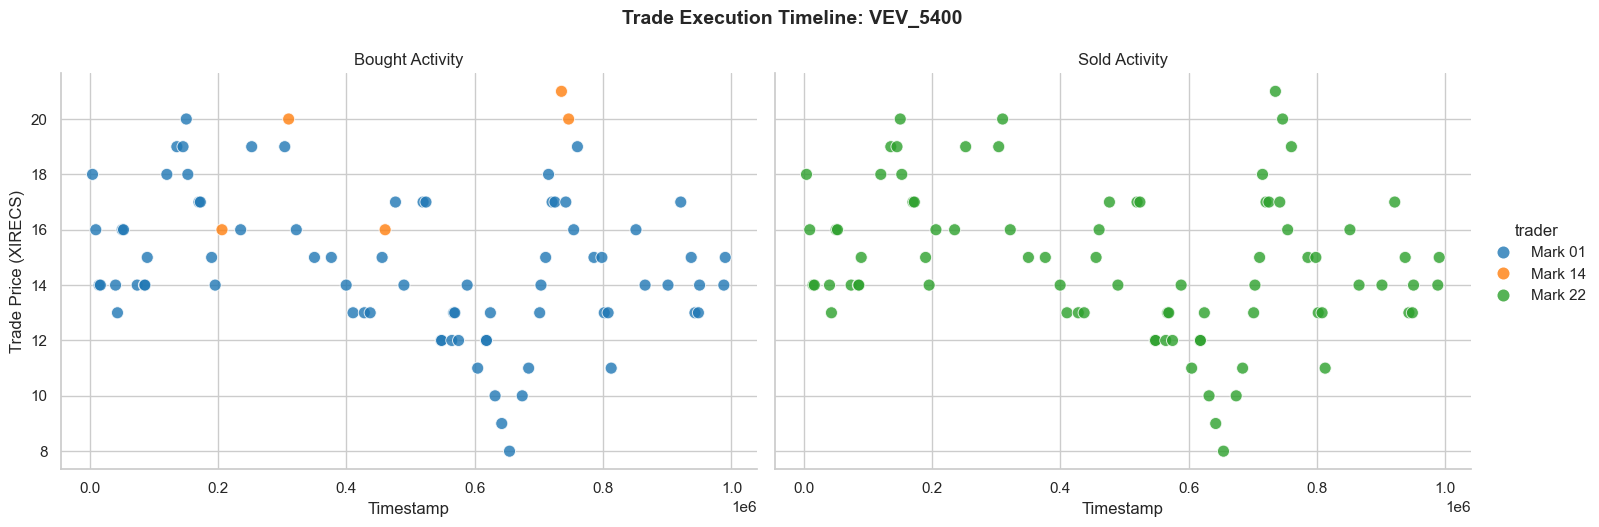

In [21]:
plot_product_activity(trades_one, 'VEV_5400')

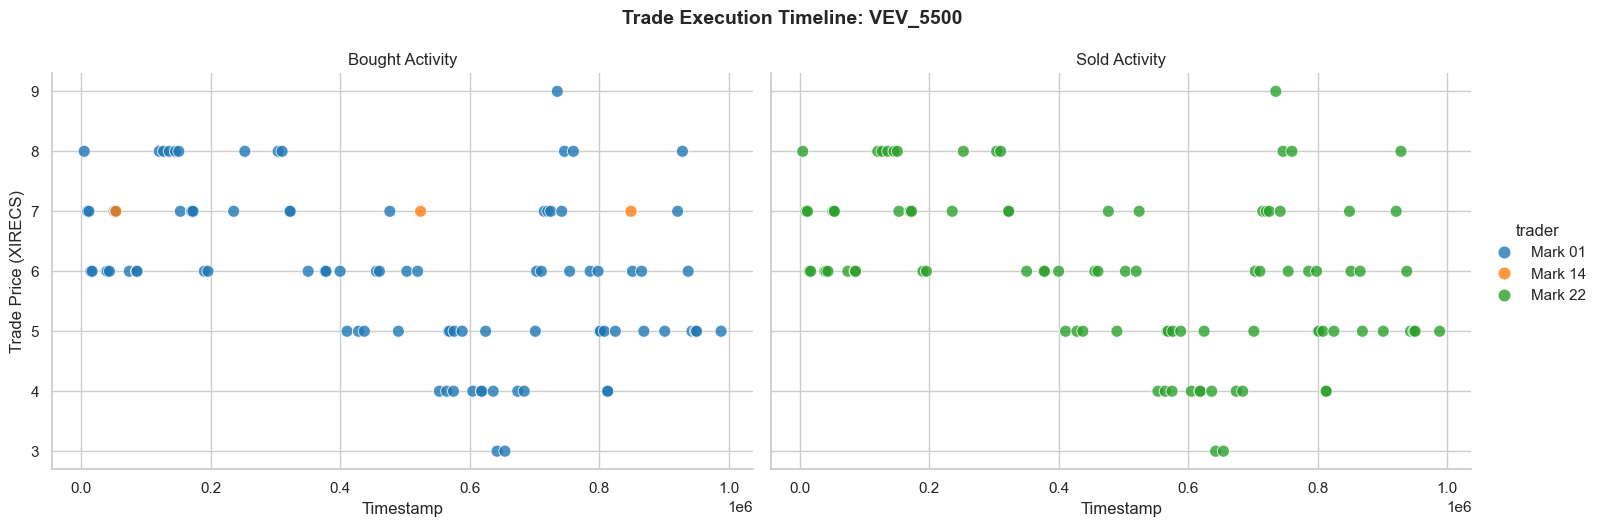

In [22]:
plot_product_activity(trades_one, 'VEV_5500')

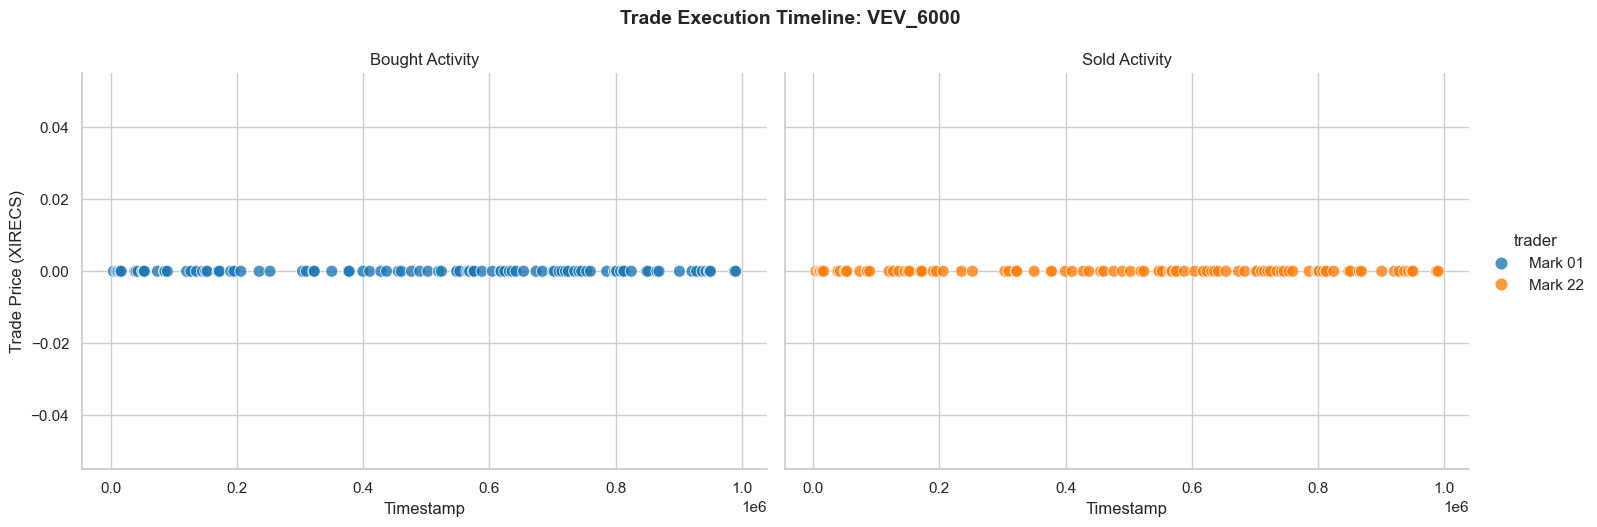

In [23]:
plot_product_activity(trades_one, 'VEV_6000')

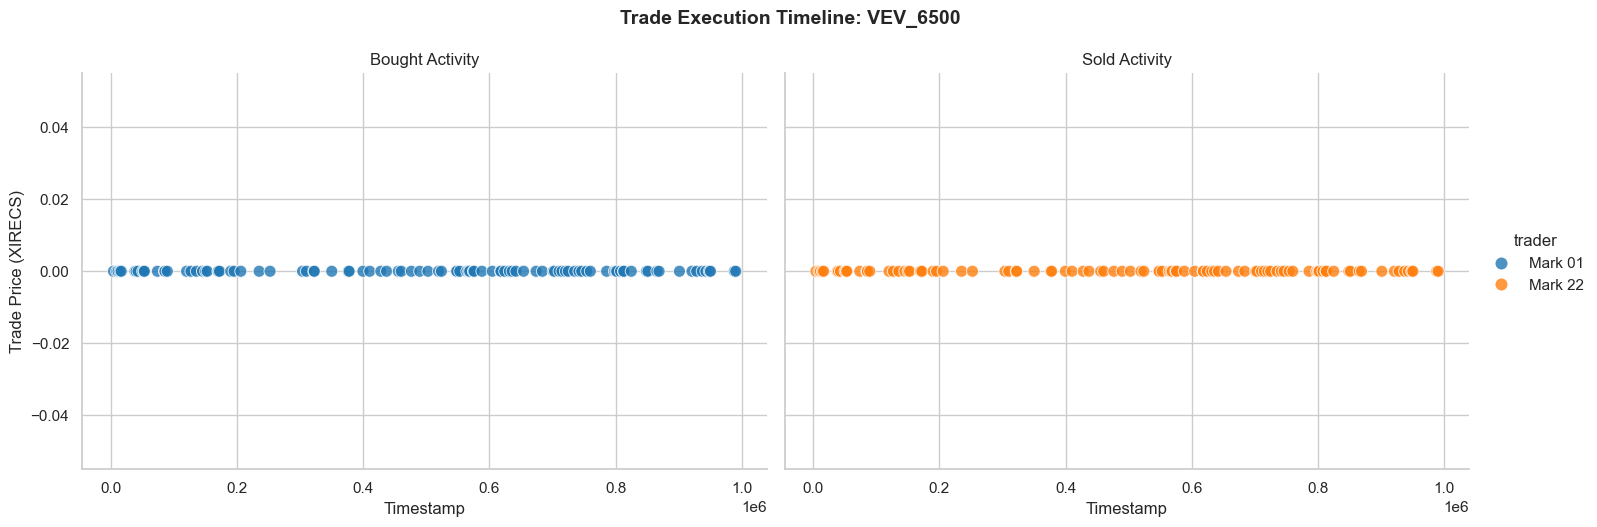

In [24]:
plot_product_activity(trades_one, 'VEV_6500')

**Day 2 trade timelines** — same per-product `plot_product_activity` calls using **`trades_two`**. Pattern as day 1: HYDRO, VELVET, then the full VEV strip.


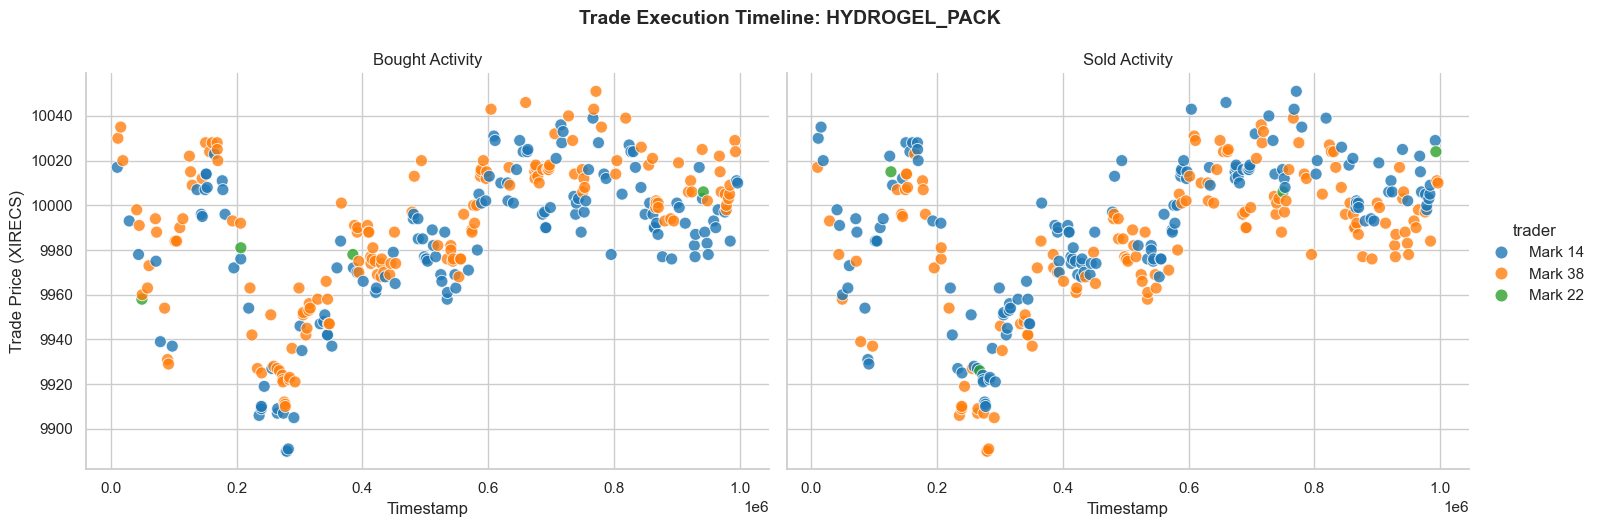

In [25]:
plot_product_activity(trades_two, 'HYDROGEL_PACK')

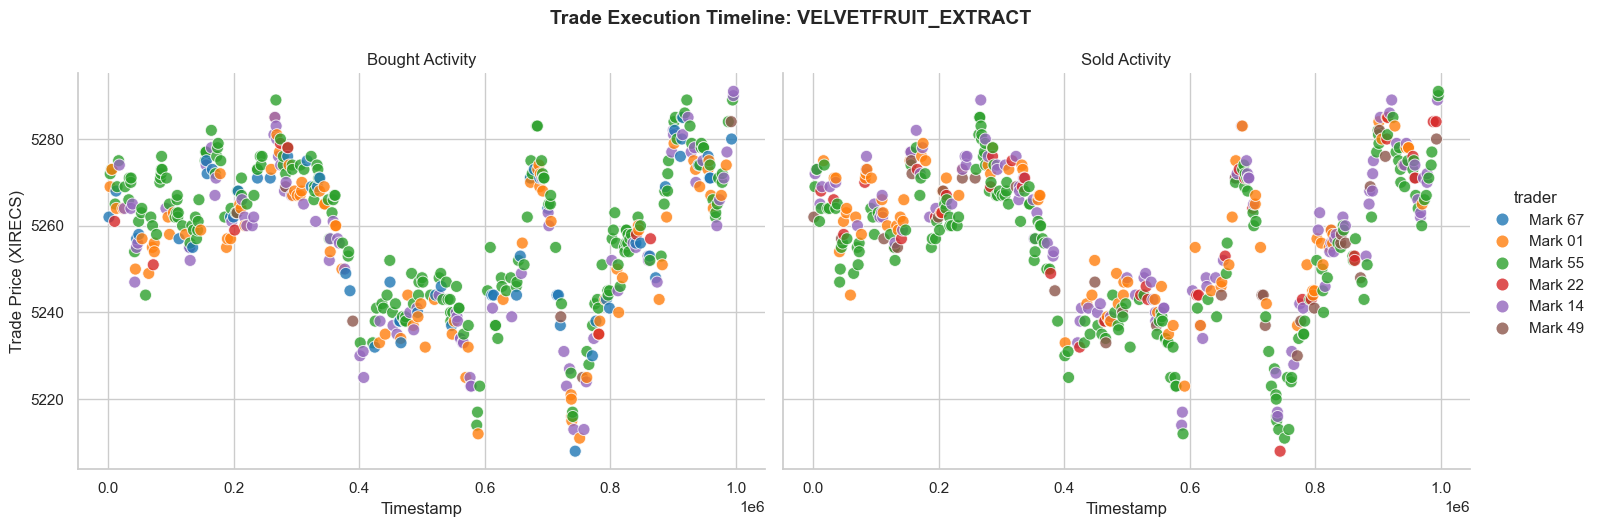

In [26]:
plot_product_activity(trades_two, 'VELVETFRUIT_EXTRACT')

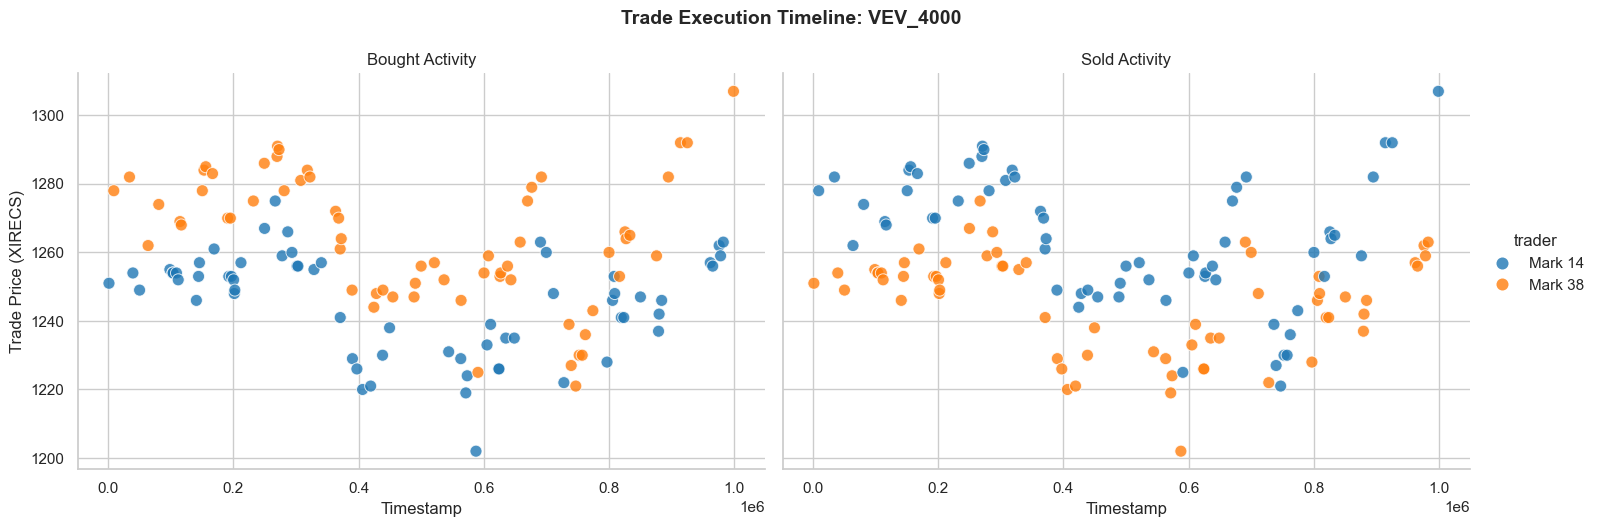

In [27]:
plot_product_activity(trades_two, 'VEV_4000')

In [28]:
plot_product_activity(trades_two, 'VEV_4500')

No trading data found for product: VEV_4500


In [29]:
plot_product_activity(trades_two, 'VEV_5000')

No trading data found for product: VEV_5000


In [30]:
plot_product_activity(trades_two, 'VEV_5100')

No trading data found for product: VEV_5100


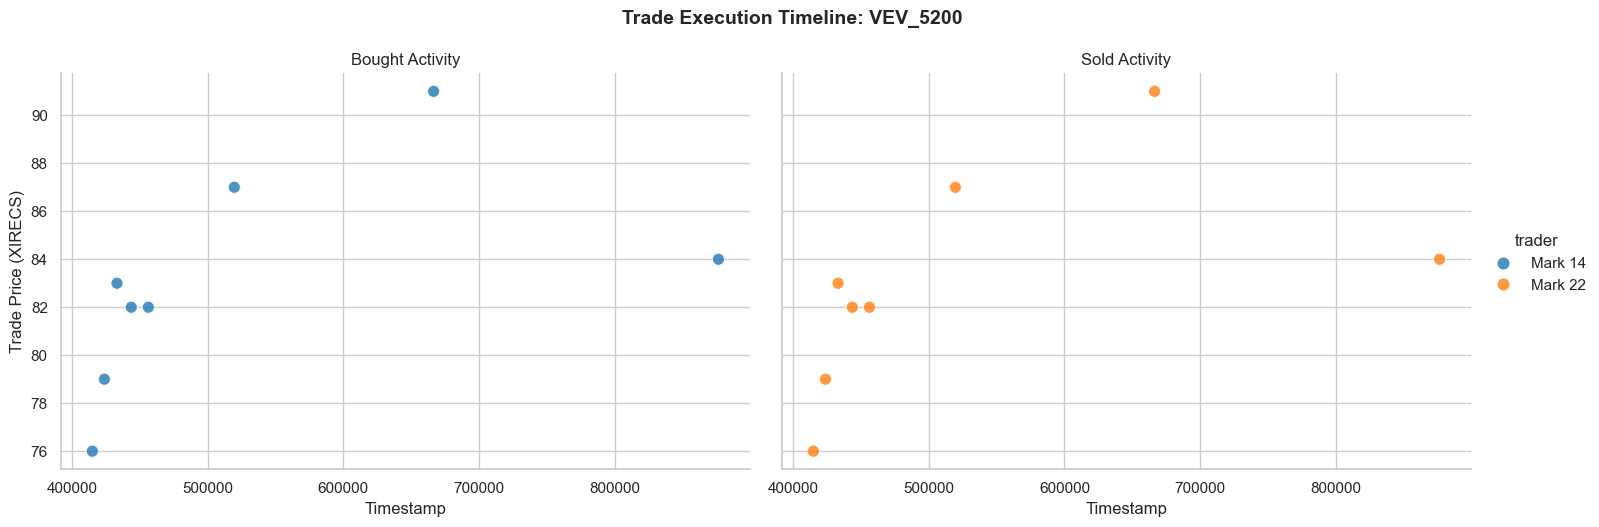

In [31]:
plot_product_activity(trades_two, 'VEV_5200')

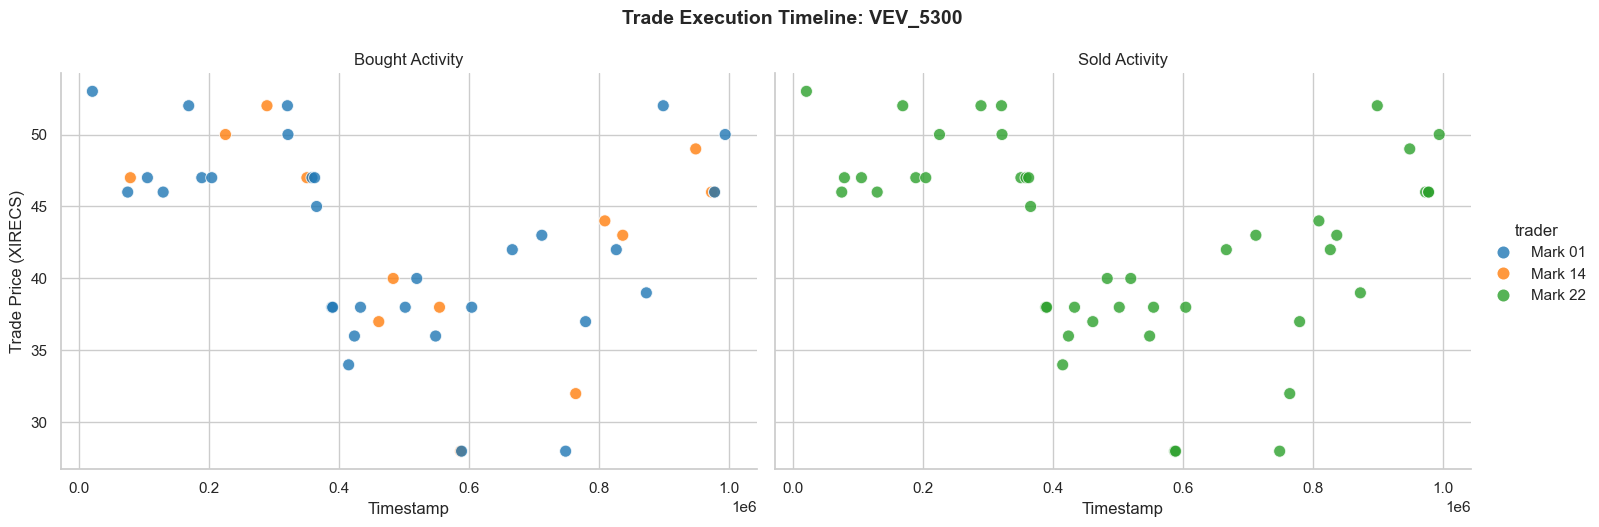

In [32]:
plot_product_activity(trades_two, 'VEV_5300')

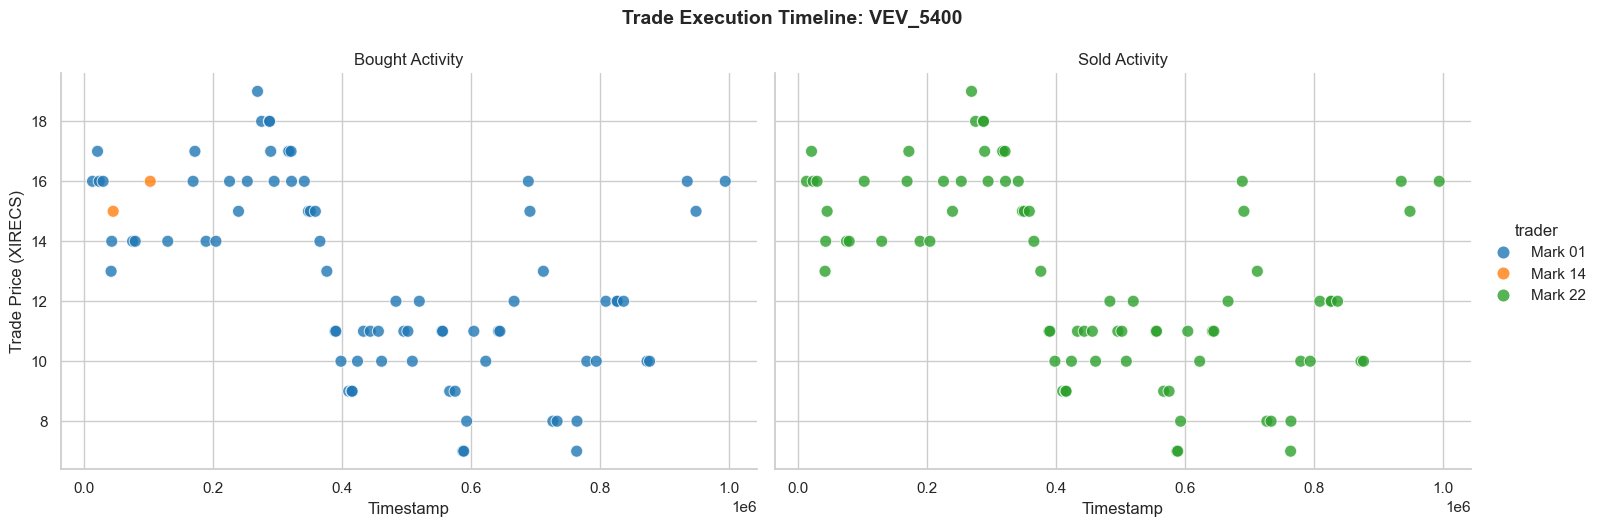

In [33]:
plot_product_activity(trades_two, 'VEV_5400')

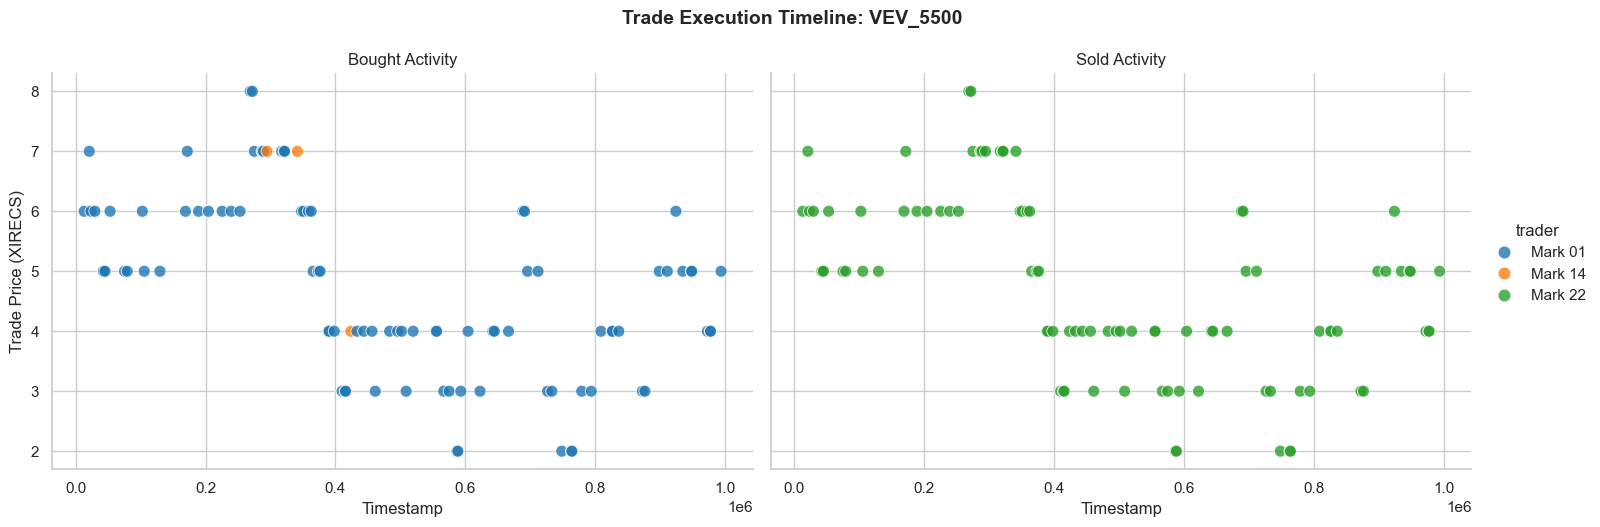

In [34]:
plot_product_activity(trades_two, 'VEV_5500')

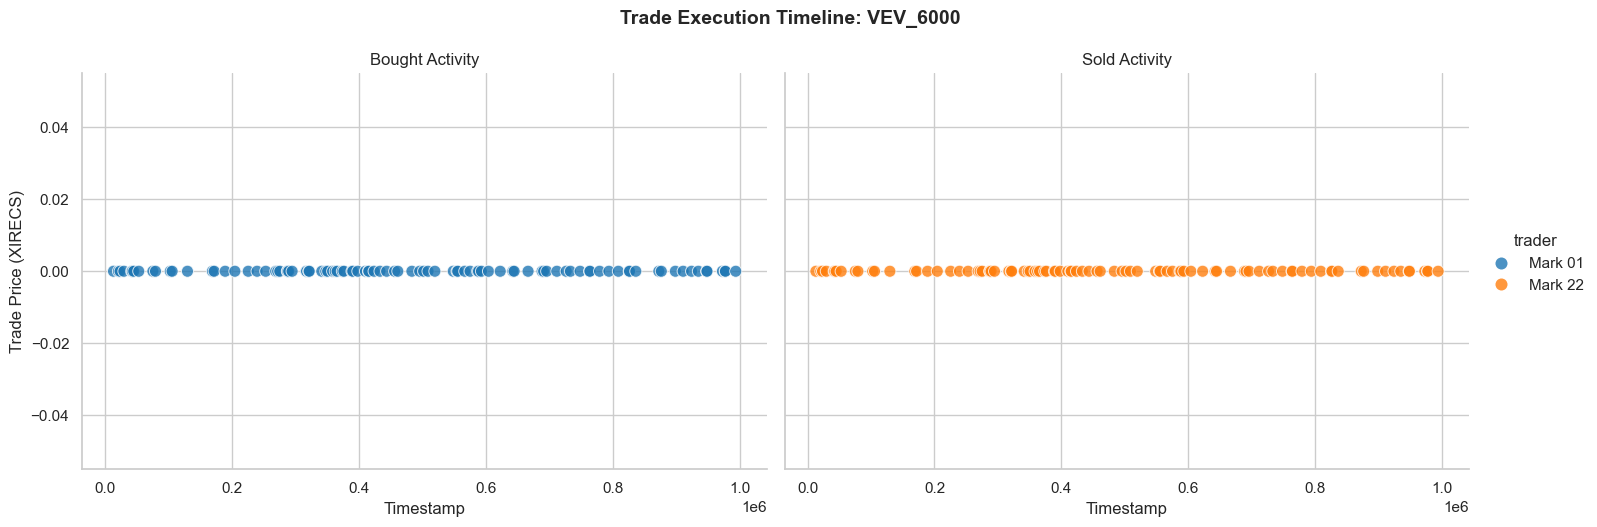

In [35]:
plot_product_activity(trades_two, 'VEV_6000')

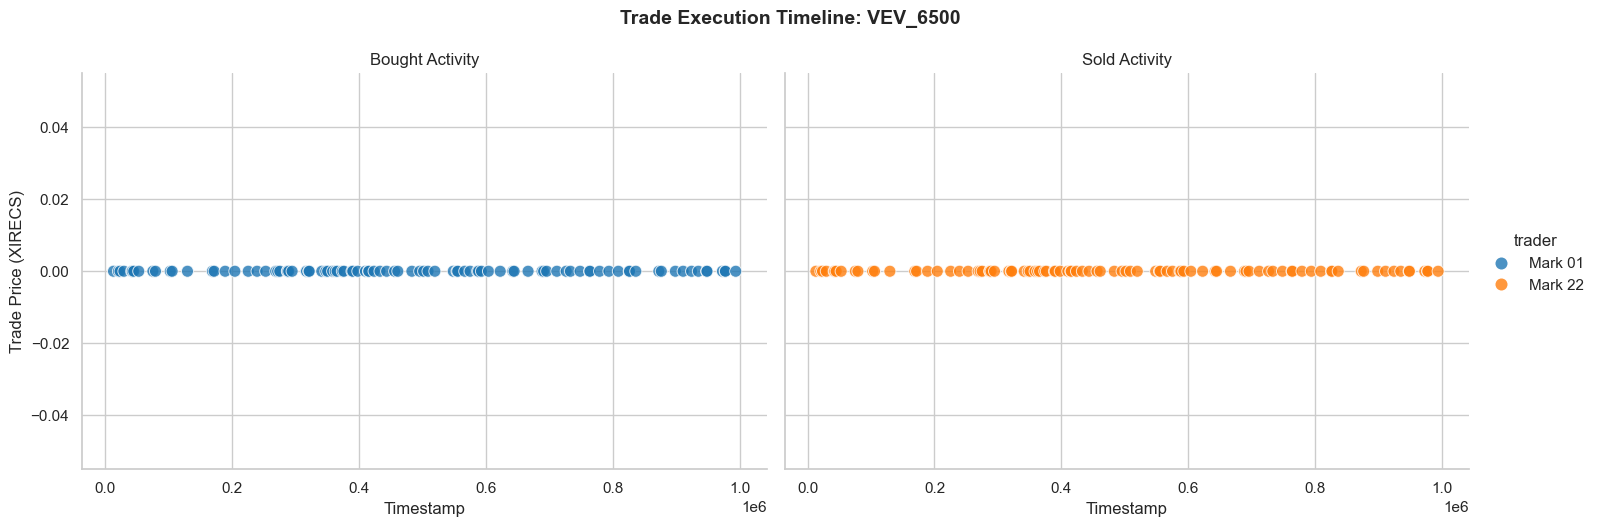

In [36]:
plot_product_activity(trades_two, 'VEV_6500')

**Day 3 trade timelines (partial grid)** — the notebook only plots a **subset** of symbols on `trades_three` (e.g. **VEV_4500** through **VEV_6500** in the file as it stands). If you need **HYDROGEL / VELVET / VEV_4000** for day 3, add the corresponding `plot_product_activity(trades_three, '...')` cells here.


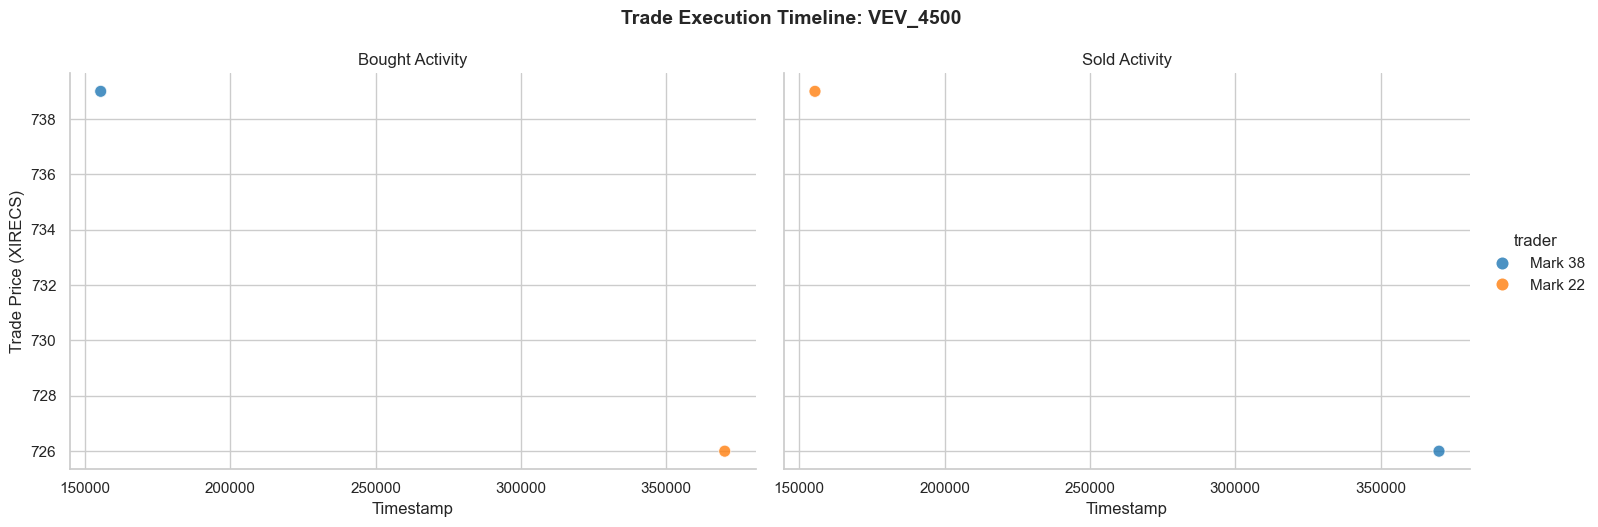

In [37]:
plot_product_activity(trades_three, 'VEV_4500')

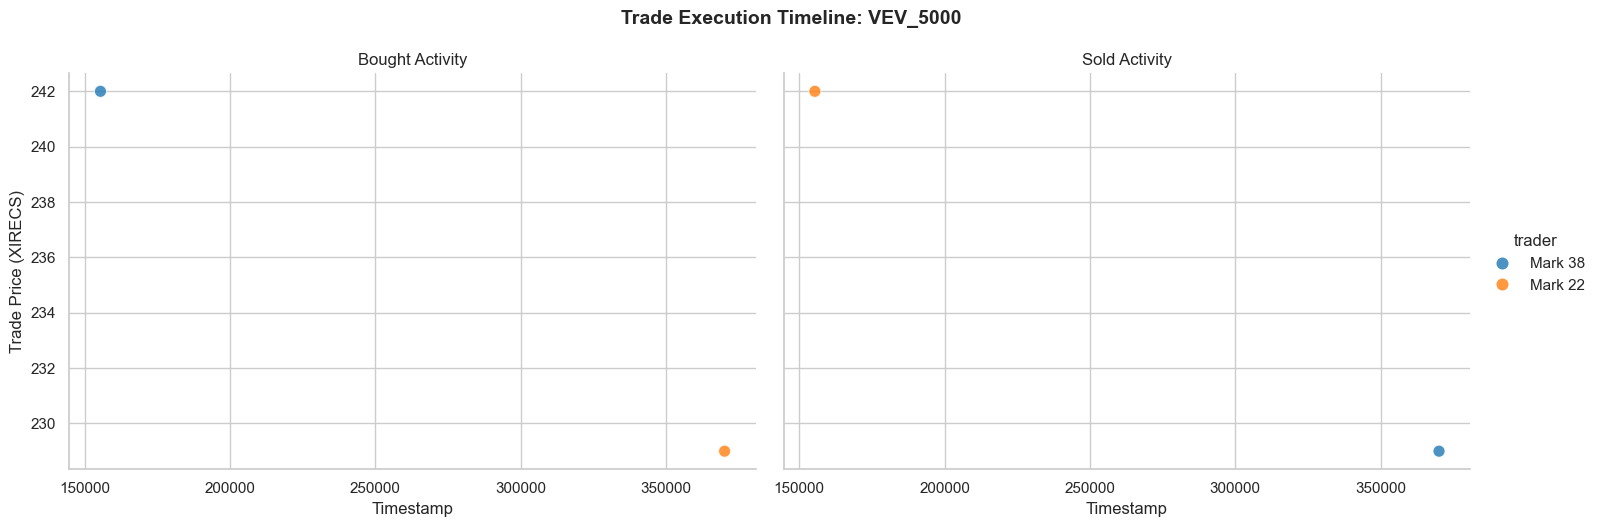

In [38]:
plot_product_activity(trades_three, 'VEV_5000')

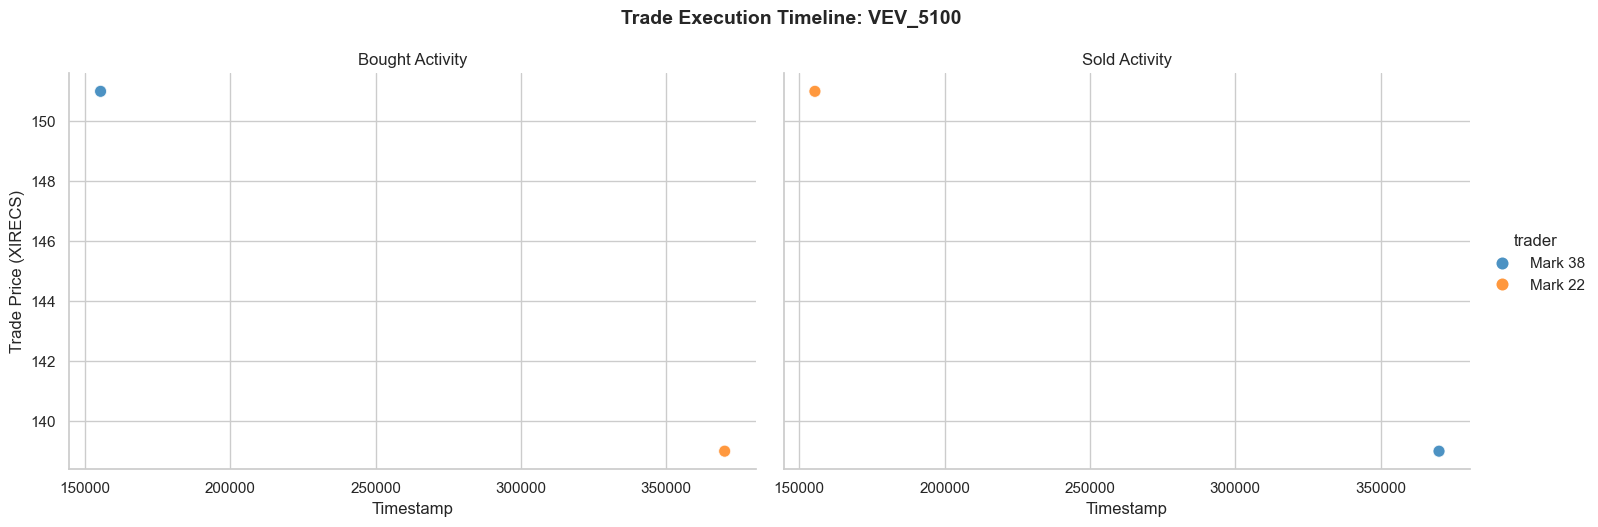

In [39]:
plot_product_activity(trades_three, 'VEV_5100')

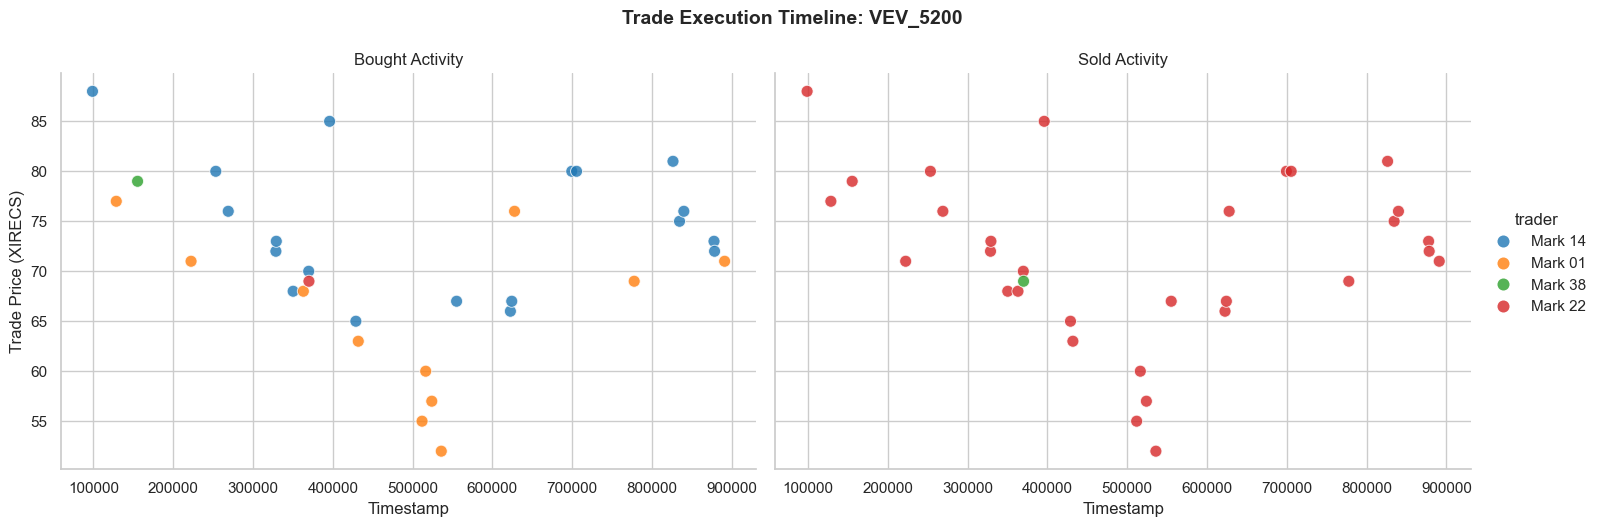

In [40]:
plot_product_activity(trades_three, 'VEV_5200')

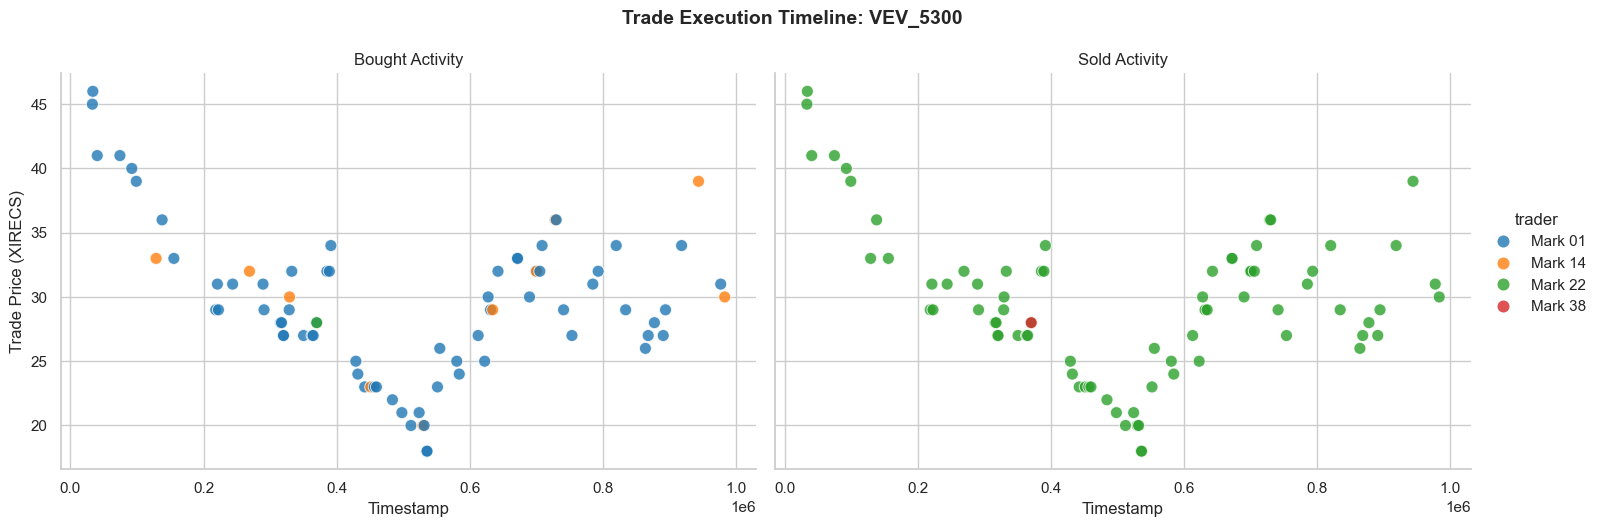

In [41]:
plot_product_activity(trades_three, 'VEV_5300')

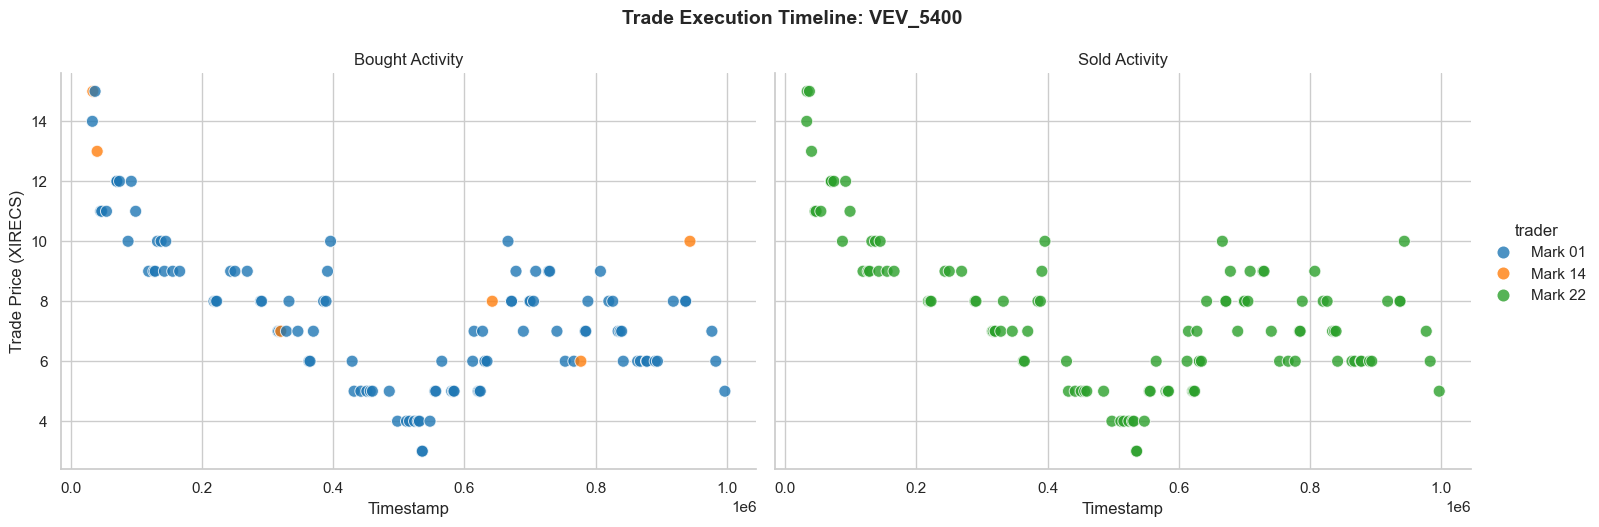

In [42]:
plot_product_activity(trades_three, 'VEV_5400')

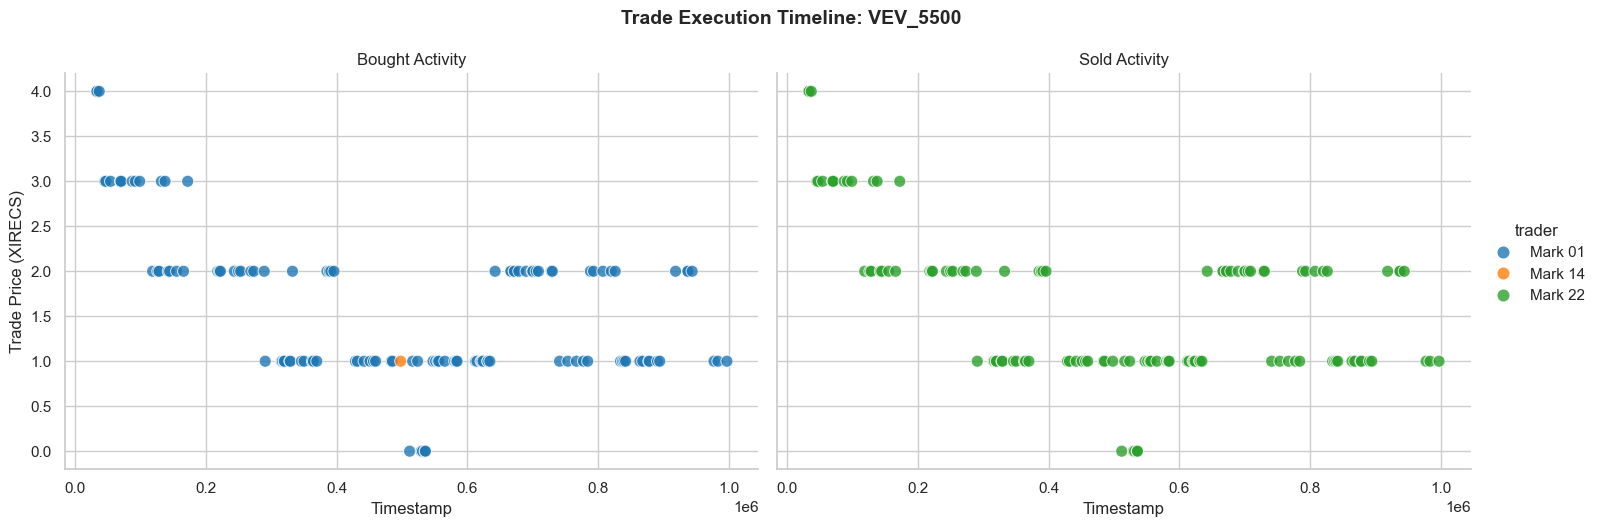

In [43]:
plot_product_activity(trades_three, 'VEV_5500')

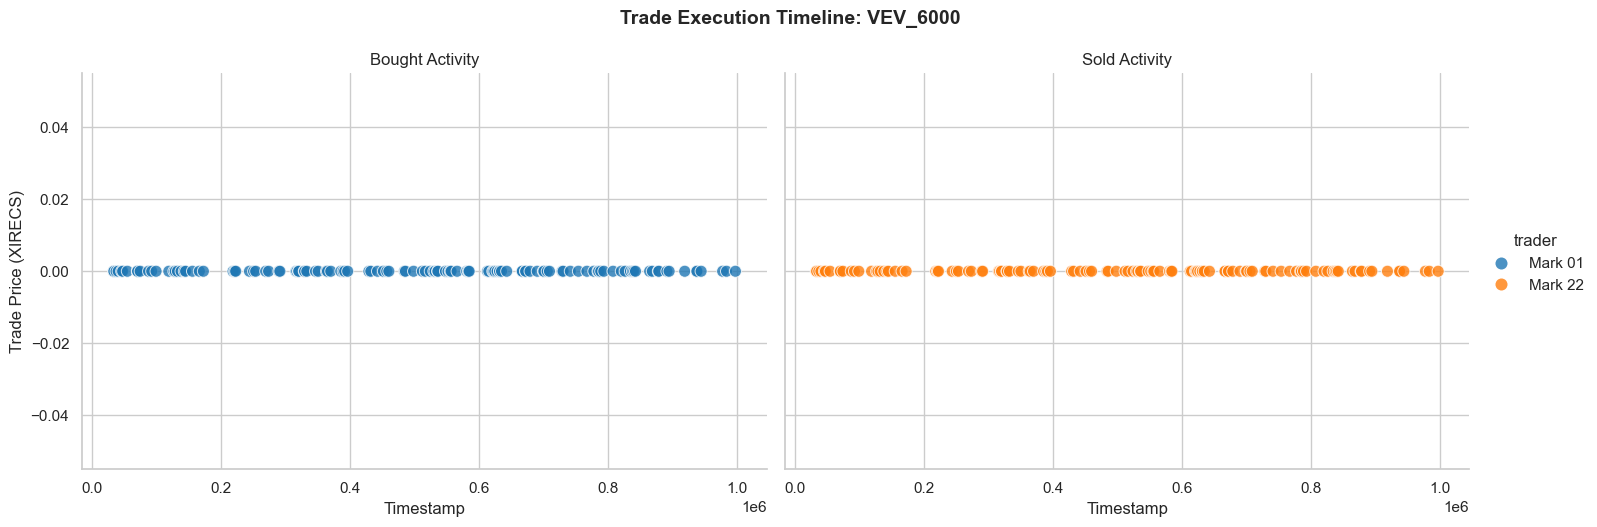

In [44]:
plot_product_activity(trades_three, 'VEV_6000')

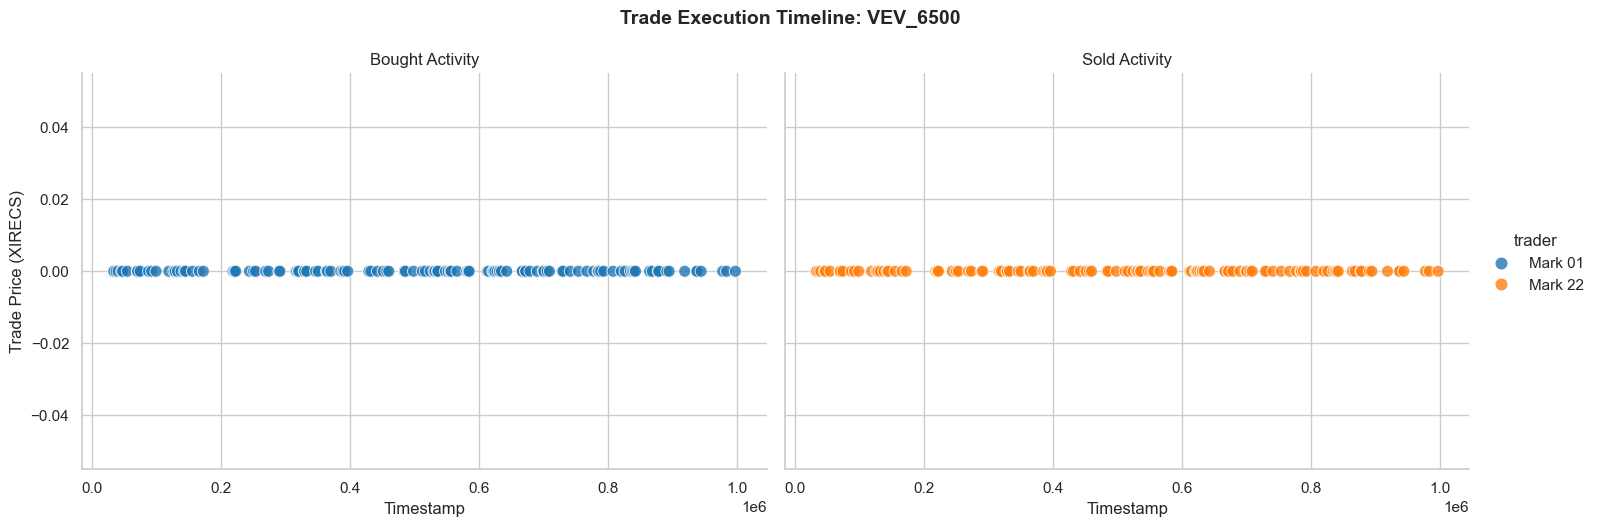

In [45]:
plot_product_activity(trades_three, 'VEV_6500')

**Trader notional (day 1)** — for every fill, `total_value = price * quantity`, then **sum** buy-side cash into `Total Bought` by `buyer` and sell-side out of `Total Sold` by `seller`, `outer` merge, fill 0, and `Net = Sold − Bought` per `Trader` string.

'''
Data analysis: this is a **gross** cashflow summary in **notional** (labels say XIRECS) — *not* economic PnL unless you net positions, fees, and MTM. Use it to see **who** traded the most **value** and whether a trader is a net taker of liquidity in aggregate on day 1.
'''


In [46]:
import pandas as pd

# Assuming your dataframe is named 'df'

# 1. Calculate the total value of each transaction
trades_one['total_value'] = trades_one['price'] * trades_one['quantity']

# 2. Calculate total amount bought (spent) for each buyer
total_bought = trades_one.groupby('buyer')['total_value'].sum().reset_index()
total_bought.rename(columns={'buyer': 'Trader', 'total_value': 'Total Bought (Spent)'}, inplace=True)

# 3. Calculate total amount sold (earned) for each seller
total_sold = trades_one.groupby('seller')['total_value'].sum().reset_index()
total_sold.rename(columns={'seller': 'Trader', 'total_value': 'Total Sold (Earned)'}, inplace=True)

# 4. Merge both sides into a unified summary table
# Using how='outer' ensures we don't lose someone who only bought or only sold
trader_summary = pd.merge(total_bought, total_sold, on='Trader', how='outer')

# Fill any missing values with 0 (e.g., if someone bought but never sold)
trader_summary = trader_summary.fillna(0)

# 5. Optional: Calculate the trader's Net Position (Earnings - Spending)
trader_summary['Net Position'] = trader_summary['Total Sold (Earned)'] - trader_summary['Total Bought (Spent)']

# Display the final summary
print(trader_summary)

    Trader  Total Bought (Spent)  Total Sold (Earned)  Net Position
0  Mark 01             2244201.0            2404594.0      160393.0
1  Mark 14            10815322.0           10260786.0     -554536.0
2  Mark 22              429652.0            1522957.0     1093305.0
3  Mark 38             7640657.0            7617731.0      -22926.0
4  Mark 49              199531.0            1795543.0     1596012.0
5  Mark 55             5307043.0            5758551.0      451508.0
6  Mark 67             2723756.0                  0.0    -2723756.0


**Trader notional (day 2)** — the **same** aggregation pattern as the previous cell applied to `trades_two` for a **second-session** view of the same `Trader` ids.


In [47]:
import pandas as pd

# Assuming your dataframe is named 'df'

# 1. Calculate the total value of each transaction
trades_two['total_value'] = trades_two['price'] * trades_two['quantity']

# 2. Calculate total amount bought (spent) for each buyer
total_bought = trades_two.groupby('buyer')['total_value'].sum().reset_index()
total_bought.rename(columns={'buyer': 'Trader', 'total_value': 'Total Bought (Spent)'}, inplace=True)

# 3. Calculate total amount sold (earned) for each seller
total_sold = trades_two.groupby('seller')['total_value'].sum().reset_index()
total_sold.rename(columns={'seller': 'Trader', 'total_value': 'Total Sold (Earned)'}, inplace=True)

# 4. Merge both sides into a unified summary table
# Using how='outer' ensures we don't lose someone who only bought or only sold
trader_summary = pd.merge(total_bought, total_sold, on='Trader', how='outer')

# Fill any missing values with 0 (e.g., if someone bought but never sold)
trader_summary = trader_summary.fillna(0)

# 5. Optional: Calculate the trader's Net Position (Earnings - Spending)
trader_summary['Net Position'] = trader_summary['Total Sold (Earned)'] - trader_summary['Total Bought (Spent)']

# Display the final summary
print(trader_summary)

    Trader  Total Bought (Spent)  Total Sold (Earned)  Net Position
0  Mark 01             2663809.0            2777199.0      113390.0
1  Mark 14             8718306.0            9857916.0     1139610.0
2  Mark 22              417895.0            1451886.0     1033991.0
3  Mark 38             6729580.0            6015399.0     -714181.0
4  Mark 49              210235.0            2102572.0     1892337.0
5  Mark 55             6259451.0            5775066.0     -484385.0
6  Mark 67             2980762.0                  0.0    -2980762.0


**Trader notional (day 3)** — same for `trades_three` (if some traders never appear, they may be missing or only all-zero after merge; `fillna(0)` keeps the table rectangular).


In [48]:
import pandas as pd

# Assuming your dataframe is named 'df'

# 1. Calculate the total value of each transaction
trades_three['total_value'] = trades_three['price'] * trades_three['quantity']

# 2. Calculate total amount bought (spent) for each buyer
total_bought = trades_three.groupby('buyer')['total_value'].sum().reset_index()
total_bought.rename(columns={'buyer': 'Trader', 'total_value': 'Total Bought (Spent)'}, inplace=True)

# 3. Calculate total amount sold (earned) for each seller
total_sold = trades_three.groupby('seller')['total_value'].sum().reset_index()
total_sold.rename(columns={'seller': 'Trader', 'total_value': 'Total Sold (Earned)'}, inplace=True)

# 4. Merge both sides into a unified summary table
# Using how='outer' ensures we don't lose someone who only bought or only sold
trader_summary = pd.merge(total_bought, total_sold, on='Trader', how='outer')

# Fill any missing values with 0 (e.g., if someone bought but never sold)
trader_summary = trader_summary.fillna(0)

# 5. Optional: Calculate the trader's Net Position (Earnings - Spending)
trader_summary['Net Position'] = trader_summary['Total Sold (Earned)'] - trader_summary['Total Bought (Spent)']

# Display the final summary
print(trader_summary)

    Trader  Total Bought (Spent)  Total Sold (Earned)  Net Position
0  Mark 01             2557341.0            2038286.0     -519055.0
1  Mark 14            10151124.0            9986328.0     -164796.0
2  Mark 22              345303.0            1057122.0      711819.0
3  Mark 38             6807254.0            7228292.0      421038.0
4  Mark 49              193707.0            1724848.0     1531141.0
5  Mark 55             5517434.0            5759219.0      241785.0
6  Mark 67             2221932.0                  0.0    -2221932.0
